# Import Libraries

In [1]:
# Import Basic Libraries
import os
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from pandas.plotting import scatter_matrix

# Scikit Packages
from sklearn import metrics
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import explained_variance_score

# Train Data
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

%matplotlib inline

from scipy import stats
from scipy.stats import norm, skew

import warnings
warnings.filterwarnings("ignore")

<a id = "2"></a><br>
# Load Dataset

In [2]:
data = pd.read_csv('auto-mpg.csv')
data.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [3]:
data.tail(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
388,26.0,4,156.0,92,2585,14.5,82,1,chrysler lebaron medallion
389,22.0,6,232.0,112,2835,14.7,82,1,ford granada l
390,32.0,4,144.0,96,2665,13.9,82,3,toyota celica gt
391,36.0,4,135.0,84,2370,13.0,82,1,dodge charger 2.2
392,27.0,4,151.0,90,2950,17.3,82,1,chevrolet camaro
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger
397,31.0,4,119.0,82,2720,19.4,82,1,chevy s-10


 ### Attribute Information:
 
 1. **MPG**: The fuel economy of an automobile is the relationship between the distance traveled and the amount of fuel consumed by the vehicle. MPG is continuous from 9 to 48 (Continuous). 
 
 2. **Cylinders**: A cylinder is the power unit of an engine; it's the chamber where the gasoline is burned and turned into power. Number of cylinder continuous from 3 to 8 (Multi-Valued Discrete) 
 
 3. **Displacement**: Engine displacement is the measure of the cylinder volume swept by all of the pistons of a piston engine, excluding the combustion chambers. Displacement is continuous from 68 to 455 (Continuous) 
 
 4. **Horsepower**: Horsepower is a unit of power used to measure the forcefulness of a vehicle's engine. Horse power continuous from 46 to 230 (Continuous). 
 
 5. **Weight**: The weight of an object is related to the amount of force acting on the object, either due to gravity or to a reaction force that holds it in place. The weight of car continuous from 1613 to 5140 (Continuous). 
 
 6. **Acceleration**: Is the rate of change of velocity of an object with respect to time. It continuous from 8 to 25 (Continuous). 
 
 7. **Model Year**: Is the year in which product is manufactured. The year ranges from 1970 to 1982 (Multi-Valued Discrete) 
 
 8. **Origin**: multi-valued discrete (USA - Japan - Euro)
 
 9. **Car Name**: string (unique for each instance)

<a id = "2"></a><br>
# Data Exploration

In [4]:
print('The dataset contains {0} rows and {1} columns.'.format(data.shape[0], data.shape[1]))

The dataset contains 398 rows and 9 columns.


In [5]:
# Checking for duplicated data
data.duplicated().sum()

0

* **From the above it is clearly observed that there is no duplicate data present in dataset.**

In [6]:
# We can see horsepower isn't shown here, we will see why soon
data.describe().round(4)

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.0000,398.0000,398.0000,398.0000,398.0000,398.0000,398.0000
mean,23.5146,5.4548,193.4259,2970.4246,15.5681,76.0101,1.5729
std,7.8160,1.7010,104.2698,846.8418,2.7577,3.6976,0.8021
min,9.0000,3.0000,68.0000,1613.0000,8.0000,70.0000,1.0000
25%,17.5000,4.0000,104.2500,2223.7500,13.8250,73.0000,1.0000
50%,23.0000,4.0000,148.5000,2803.5000,15.5000,76.0000,1.0000
75%,29.0000,8.0000,262.0000,3608.0000,17.1750,79.0000,2.0000
max,46.6000,8.0000,455.0000,5140.0000,24.8000,82.0000,3.0000


### Summary Statistics
- **Mean**: Balance Point
- **Median**: Middle Value "when ordered"
- **Variance**: The average of the squared distance of the mean
- **Standard Deviation**: The square root of the variance
- **Skewness**: A measure that describes the contrast of one tail versus the other tail. For example, if there are more high values in your distribution than low values then your distribution is 'skewed' towards the high values.
- **Kurtosis**: A measure of how 'fat' the tails in the distribution are.

In [9]:
data.skew()

mpg             0.457066
cylinders       0.526922
displacement    0.719645
weight          0.531063
acceleration    0.278777
model year      0.011535
origin          0.923776
dtype: float64

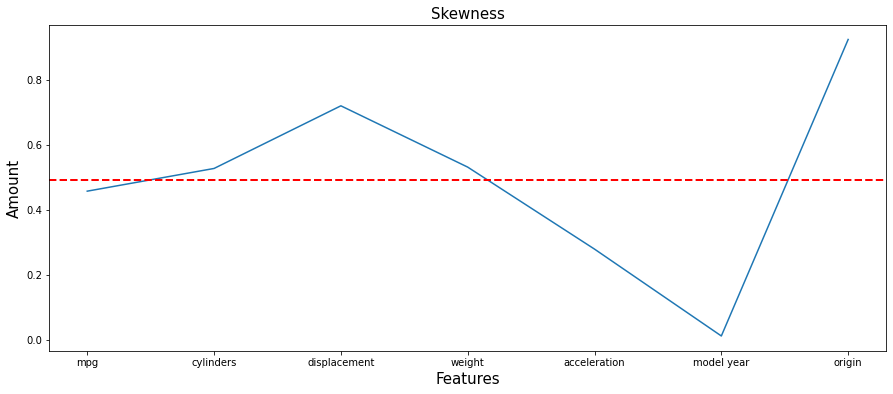

In [17]:
plt.figure(figsize = (15, 6))
plt.plot(data.skew(), marker = 'o', markersize = 10, color = 'b')
plt.axhline(data.skew().mean(), color = 'r', linestyle = 'dashed', linewidth = 2)
plt.title('Skewness', fontsize = 15)
plt.xlabel('Features', fontsize = 15)
plt.ylabel('Amount', fontsize = 15)
plt.show()

* **All Features have positive skew less than 1**

In [18]:
data['mpg'].describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

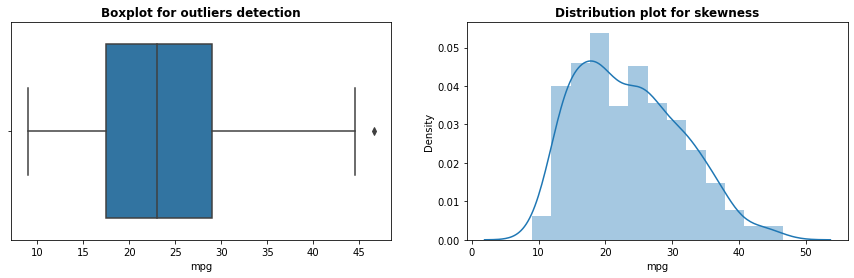

In [19]:
# visualizing our dependent variable for outliers and skewnwss
plt.figure(figsize = (15, 4))

plt.subplot(1, 2, 1)
sns.boxplot(data['mpg'])
plt.title("Boxplot for outliers detection", fontweight = 'bold')

plt.subplot(1, 2, 2)
sns.distplot(data['mpg'])
plt.title("Distribution plot for skewness", fontweight = 'bold')

plt.show()

In [20]:
print("Skewness: %f" % data['mpg'].skew())
print("Kurtosis: %f" % data['mpg'].kurt())

Skewness: 0.457066
Kurtosis: -0.510781


* **From the above it is observed that target variable is almost normally distributed.**

In [21]:
data.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [122]:
# horsepower is an object, so something must be wrong with the values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [123]:
# checking for any null values 
data.isnull().any()

mpg             False
cylinders       False
displacement    False
horsepower      False
weight          False
acceleration    False
model year      False
origin          False
car name        False
dtype: bool

In [124]:
# checking if 'horsepower' has any missing values
data['horsepower'].isnull().sum()

0

In [125]:
# Copy dataframe to save progress at this checkpoint
checkpoint1 = data.copy(deep = True)

In [126]:
# Load this cell instead of starting from beginning
data = checkpoint1.copy(deep = True)

<a id = "2"></a><br>
# Data Preprocessing

We can see that **car names** is obviously an object as it contain strings, but is knowing the name of the car important to the rest of the dataset? Besides being able to compare car features while knowing what the car name and manufactuiring name is, no, so we can drop that column.

If we did keep **car names**, then we would have to seperate and organize the car name and manufacturer.

(Also I just don't want to have to deal with car names and manufacturing names. We can use the backup data if we need to view them)

In [127]:
# drop car name column
data.drop(['car name'], axis = 1, inplace = True)
data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


* **Now we look at horsepower to see what is going on..**

In [128]:
# list of all unique values in horsepower
data['horsepower'].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

* It looks like there are **`?`** values in horsepower. That is because pandas coerced the entire column as an object when we imported the data set due to **`?`**. Lets see how many there are and if we should keep or remove them. 

In [129]:
# calculate how many are '?' values in horsepower
data[data['horsepower'] == '?']

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
32,25.0,4,98.0,?,2046,19.0,71,1
126,21.0,6,200.0,?,2875,17.0,74,1
330,40.9,4,85.0,?,1835,17.3,80,2
336,23.6,4,140.0,?,2905,14.3,80,1
354,34.5,4,100.0,?,2320,15.8,81,2
374,23.0,4,151.0,?,3035,20.5,82,1


We can see there are 6 records with **`?`** values in horsepower

**We have two choices for `?` values:**
1. Remove those records from the data set
2. Replace the **`?`** values with some central values

First we need to convert those **`?`** into NaN values

In [130]:
# replace ? with NaN and convert horsepower from object to float (continuous)
data['horsepower'] = pd.to_numeric(data['horsepower'], errors = 'coerce')

In [131]:
# let's print these 6 NaN containing rows 
data[data['horsepower'].isnull()]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
32,25.0,4,98.0,NaN,2046,19.0,71,1
126,21.0,6,200.0,NaN,2875,17.0,74,1
330,40.9,4,85.0,NaN,1835,17.3,80,2
336,23.6,4,140.0,NaN,2905,14.3,80,1
354,34.5,4,100.0,NaN,2320,15.8,81,2
374,23.0,4,151.0,NaN,3035,20.5,82,1


In [132]:
# The missing values in horsepower only account for 1.5% of the data, so we could remove them if we wanted to
6 / len(data)

0.01507537688442211

In [133]:
# We can double check once replacing ? with NaN that there is 6 missing values
data['horsepower'].isnull().sum()

6

In [134]:
data.isnull().any()

mpg             False
cylinders       False
displacement    False
horsepower       True
weight          False
acceleration    False
model year      False
origin          False
dtype: bool

In [135]:
# horsepower is now a float
data.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
dtype: object

In [136]:
data['horsepower'].describe()

count    392.000000
mean     104.469388
std       38.491160
min       46.000000
25%       75.000000
50%       93.500000
75%      126.000000
max      230.000000
Name: horsepower, dtype: float64

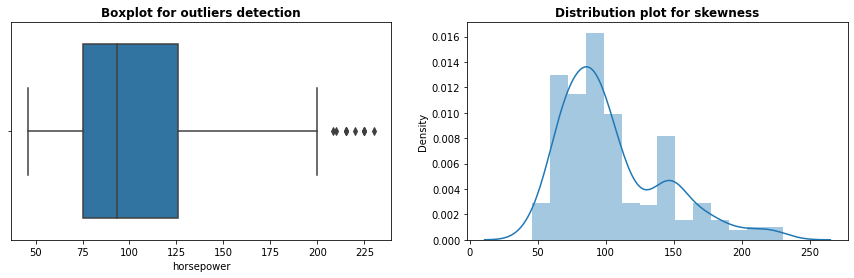

In [137]:
# Visualizing 'Horsepower' feature for outliers and skewnwss
plt.figure(figsize = (15, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x = data['horsepower'])
plt.title("Boxplot for outliers detection", fontweight = 'bold')

plt.subplot(1, 2, 2)
sns.distplot(x = data['horsepower'])
plt.title("Distribution plot for skewness", fontweight = 'bold')

plt.show()

* **From the above plots it is observed the `Horsepower` column contains `few outliers` in upper boundary and it is `Right Skewed`**. 
* **So `replacing null values with Median` instead of Mean**.

In [138]:
# Now we can replace the NaN values with median value from horsepower
data['horsepower'].fillna(data['horsepower'].median(), inplace = True)

In [139]:
# Now there is no missing data
data["horsepower"].isnull().sum()

0

In [140]:
data.isnull().any()

mpg             False
cylinders       False
displacement    False
horsepower      False
weight          False
acceleration    False
model year      False
origin          False
dtype: bool

In [141]:
data.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.304020,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.222625,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,76.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## Covariance 
* Covariance is a measure of how much two random variables vary together.

* If two variables are independent, their covariance is 0. However, a covariance of 0 does not imply that the variables are independent.
* (+) : positive relation
* (-) : negtive relation

In [142]:
data.cov()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,61.089611,-10.308911,-655.402318,-231.067162,-5505.211745,9.058930,16.741163,3.532185
cylinders,-10.308911,2.893415,168.623214,54.697663,1290.695575,-2.370842,-2.193499,-0.767477
displacement,-655.402318,168.623214,10872.199152,3570.094379,82368.423240,-156.332976,-142.717137,-50.964989
horsepower,-231.067162,54.697663,3570.094379,1460.969052,27915.978893,-72.370753,-58.474096,-13.859740
weight,-5505.211745,1290.695575,82368.423240,27915.978893,717140.990526,-974.899011,-959.946344,-394.639330
acceleration,9.058930,-2.370842,-156.332976,-72.370753,-974.899011,7.604848,2.938105,0.455354
model year,16.741163,-2.193499,-142.717137,-58.474096,-959.946344,2.938105,13.672443,0.535790
origin,3.532185,-0.767477,-50.964989,-13.859740,-394.639330,0.455354,0.535790,0.643292


## Correlation 
* Correlation is a standardized version of covariance.
* Between -1 and 1
* Zero = Not correlated
* (+) : positive relation
* (-) : negtive relation

In [143]:
corrmat = data.corr()
corrmat

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,1.000000,-0.775396,-0.804203,-0.773453,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.841284,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.895778,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.773453,0.841284,0.895778,1.000000,0.862442,-0.686590,-0.413733,-0.452096
weight,-0.831741,0.896017,0.932824,0.862442,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.686590,-0.417457,1.000000,0.288137,0.205873
model year,0.579267,-0.348746,-0.370164,-0.413733,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.452096,-0.581024,0.205873,0.180662,1.000000


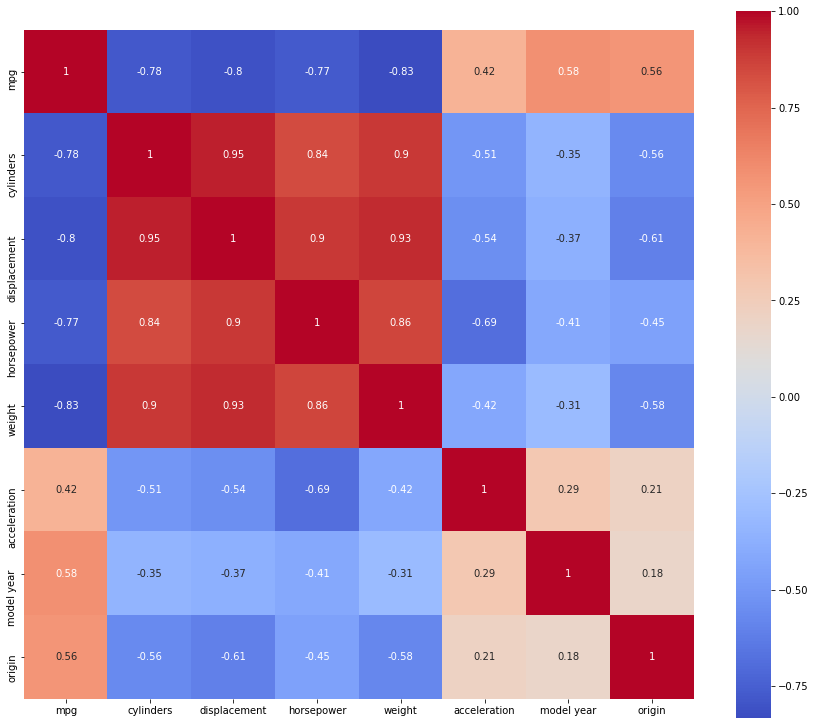

In [144]:
plt.figure(figsize = (15, 13))
sns.heatmap(corrmat, cmap = 'coolwarm', square = True, annot = True);

In [145]:
corrmat.style.background_gradient(cmap = 'coolwarm').set_precision(2)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
mpg,1.00,-0.78,-0.80,-0.77,-0.83,0.42,0.58,0.56
cylinders,-0.78,1.00,0.95,0.84,0.90,-0.51,-0.35,-0.56
displacement,-0.80,0.95,1.00,0.90,0.93,-0.54,-0.37,-0.61
horsepower,-0.77,0.84,0.90,1.00,0.86,-0.69,-0.41,-0.45
weight,-0.83,0.90,0.93,0.86,1.00,-0.42,-0.31,-0.58
acceleration,0.42,-0.51,-0.54,-0.69,-0.42,1.00,0.29,0.21
model year,0.58,-0.35,-0.37,-0.41,-0.31,0.29,1.00,0.18
origin,0.56,-0.56,-0.61,-0.45,-0.58,0.21,0.18,1.00


In [146]:
data_corr = data.corr().abs().unstack().sort_values(kind = 'quicksort', ascending = False).reset_index()
data_corr.rename(columns = {"level_0": "Feature A", 
                            "level_1": "Feature B", 0: 'Correlation Coefficient'}, inplace = True)
data_corr[data_corr['Feature A'] == 'horsepower'].style.background_gradient(cmap = 'summer_r')

,Feature A,Feature B,Correlation Coefficient
4,horsepower,horsepower,1.000000
15,horsepower,displacement,0.895778
16,horsepower,weight,0.862442
19,horsepower,cylinders,0.841284
27,horsepower,mpg,0.773453
28,horsepower,acceleration,0.686590
45,horsepower,origin,0.452096
50,horsepower,model year,0.413733


In [147]:
data_corr = data.corr().abs().unstack().sort_values(kind = 'quicksort', ascending = False).reset_index()
data_corr.rename(columns = {"level_0": "Feature A", 
                            "level_1": "Feature B", 0: 'Correlation Coefficient'}, inplace = True)
data_corr[data_corr['Feature A'] == 'displacement'].style.background_gradient(cmap = 'summer_r')

,Feature A,Feature B,Correlation Coefficient
3,displacement,displacement,1.000000
8,displacement,cylinders,0.950721
11,displacement,weight,0.932824
14,displacement,horsepower,0.895778
23,displacement,mpg,0.804203
30,displacement,origin,0.609409
40,displacement,acceleration,0.543684
52,displacement,model year,0.370164


In [148]:
data_corr = data.corr().abs().unstack().sort_values(kind = 'quicksort', ascending = False).reset_index()
data_corr.rename(columns = {"level_0": "Feature A", 
                            "level_1": "Feature B", 0: 'Correlation Coefficient'}, inplace = True)
data_corr[data_corr['Feature A'] == 'weight'].style.background_gradient(cmap = 'summer_r')

,Feature A,Feature B,Correlation Coefficient
5,weight,weight,1.000000
10,weight,displacement,0.932824
12,weight,cylinders,0.896017
17,weight,horsepower,0.862442
21,weight,mpg,0.831741
32,weight,origin,0.581024
48,weight,acceleration,0.417457
56,weight,model year,0.306564


In [149]:
data_corr = data.corr().abs().unstack().sort_values(kind = 'quicksort', ascending = False).reset_index()
data_corr.rename(columns = {"level_0": "Feature A", 
                            "level_1": "Feature B", 0: 'Correlation Coefficient'}, inplace = True)
data_corr[data_corr['Feature A'] == 'mpg'].style.background_gradient(cmap = 'summer_r')

,Feature A,Feature B,Correlation Coefficient
7,mpg,mpg,1.000000
20,mpg,weight,0.831741
22,mpg,displacement,0.804203
24,mpg,cylinders,0.775396
26,mpg,horsepower,0.773453
34,mpg,model year,0.579267
37,mpg,origin,0.563450
47,mpg,acceleration,0.420289


In [150]:
data_corr = data.corr().abs().unstack().sort_values(kind = 'quicksort', ascending = False).reset_index()
data_corr.rename(columns = {"level_0": "Feature A", 
                            "level_1": "Feature B", 0: 'Correlation Coefficient'}, inplace = True)
data_corr[data_corr['Feature A'] == 'acceleration'].style.background_gradient(cmap = 'summer_r')

,Feature A,Feature B,Correlation Coefficient
6,acceleration,acceleration,1.000000
29,acceleration,horsepower,0.686590
41,acceleration,displacement,0.543684
43,acceleration,cylinders,0.505419
46,acceleration,mpg,0.420289
49,acceleration,weight,0.417457
59,acceleration,model year,0.288137
60,acceleration,origin,0.205873


In [151]:
data_corr = data.corr().abs().unstack().sort_values(kind = 'quicksort', ascending = False).reset_index()
data_corr.rename(columns = {"level_0": "Feature A", 
                            "level_1": "Feature B", 0: 'Correlation Coefficient'}, inplace = True)
data_corr[data_corr['Feature A'] == 'cylinders'].style.background_gradient(cmap = 'summer_r')

,Feature A,Feature B,Correlation Coefficient
2,cylinders,cylinders,1.000000
9,cylinders,displacement,0.950721
13,cylinders,weight,0.896017
18,cylinders,horsepower,0.841284
25,cylinders,mpg,0.775396
38,cylinders,origin,0.562543
42,cylinders,acceleration,0.505419
54,cylinders,model year,0.348746


<a id = "2"></a><br>
# Plotting Data

* Lets replace the origin column values with their respective true values so we can compare the origin of cars with the other features more easily instead of having to look at the graphs with vertical or horizontal dots

In [152]:
data['origin'].replace({1:'USA', 2:'Japan', 3:'Europe'}, inplace = True)
data.head(20)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130.0,3504,12.0,70,USA
1,15.0,8,350.0,165.0,3693,11.5,70,USA
2,18.0,8,318.0,150.0,3436,11.0,70,USA
3,16.0,8,304.0,150.0,3433,12.0,70,USA
4,17.0,8,302.0,140.0,3449,10.5,70,USA
5,15.0,8,429.0,198.0,4341,10.0,70,USA
6,14.0,8,454.0,220.0,4354,9.0,70,USA
7,14.0,8,440.0,215.0,4312,8.5,70,USA
8,14.0,8,455.0,225.0,4425,10.0,70,USA
9,15.0,8,390.0,190.0,3850,8.5,70,USA


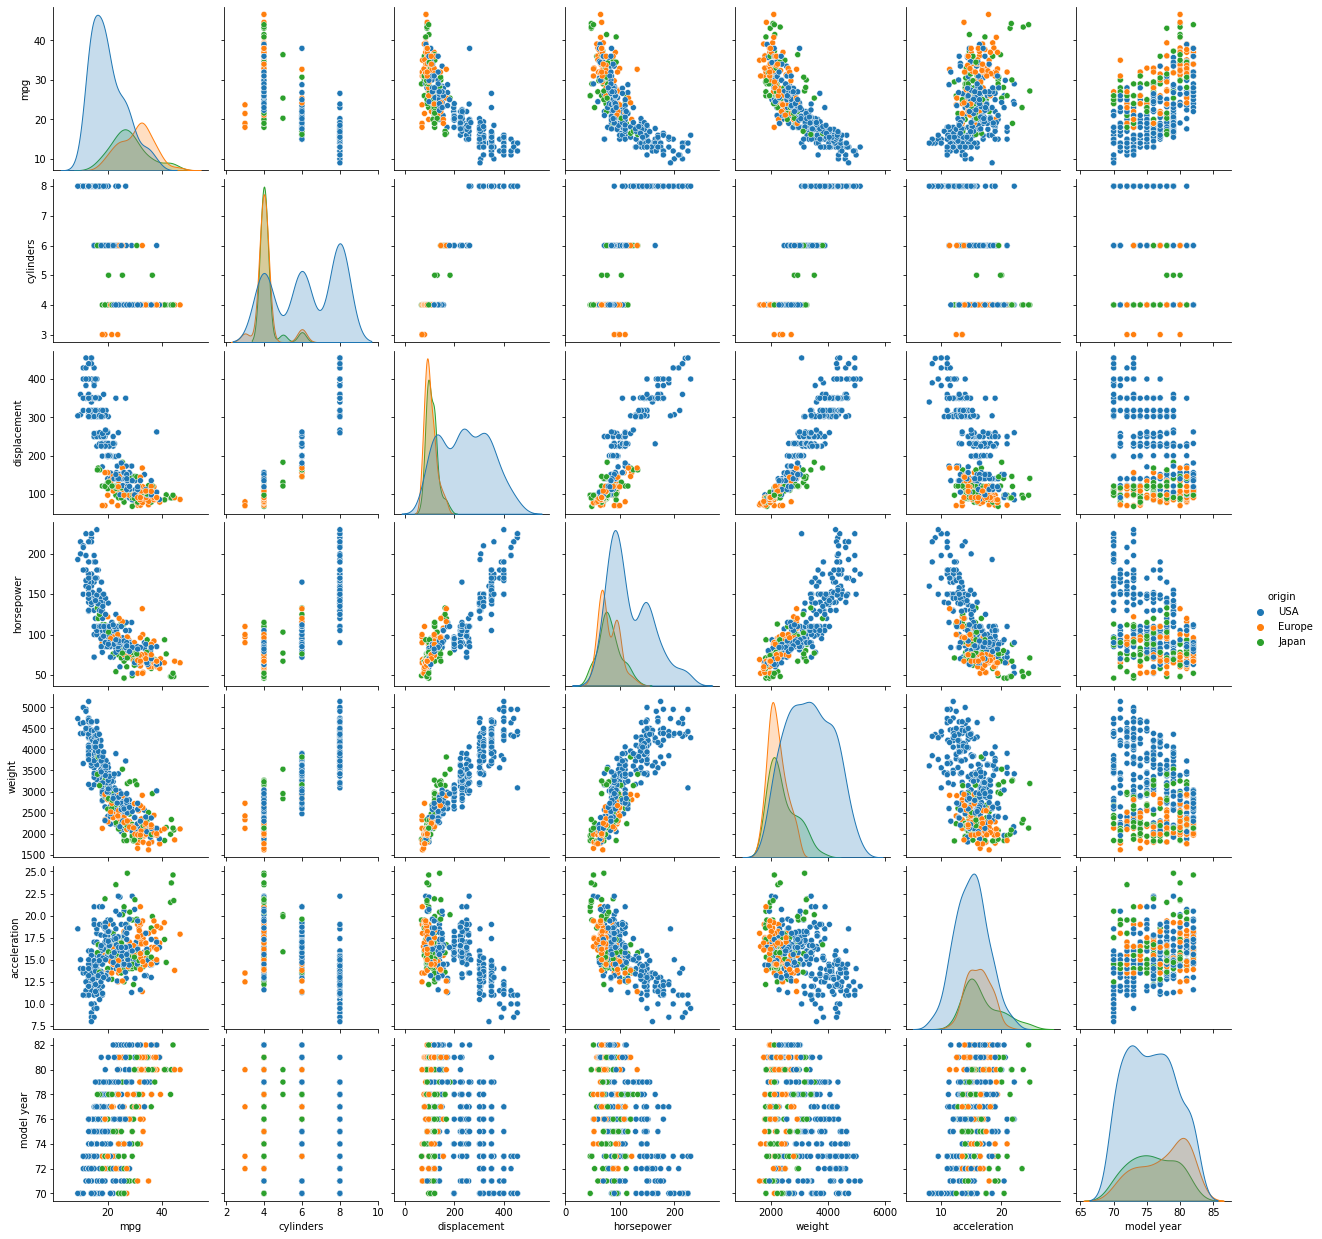

In [153]:
sns.pairplot(data, hue = 'origin')
plt.show()

First let us look at the pairplot between every feature.

* We can see
    * `cylinders` and `origin` can be categorical feature
    * and also explore about correlations between features

In [154]:
data['origin'].value_counts()

USA       249
Europe     79
Japan      70
Name: origin, dtype: int64

In [155]:
data['origin'].value_counts(normalize = True)

USA       0.625628
Europe    0.198492
Japan     0.175879
Name: origin, dtype: float64

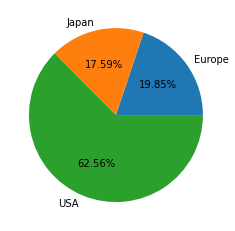

In [156]:
# Pie plot for origin
data.groupby('origin').size().plot(kind = 'pie', autopct = '%.2f%%', ylabel = '')
plt.show()

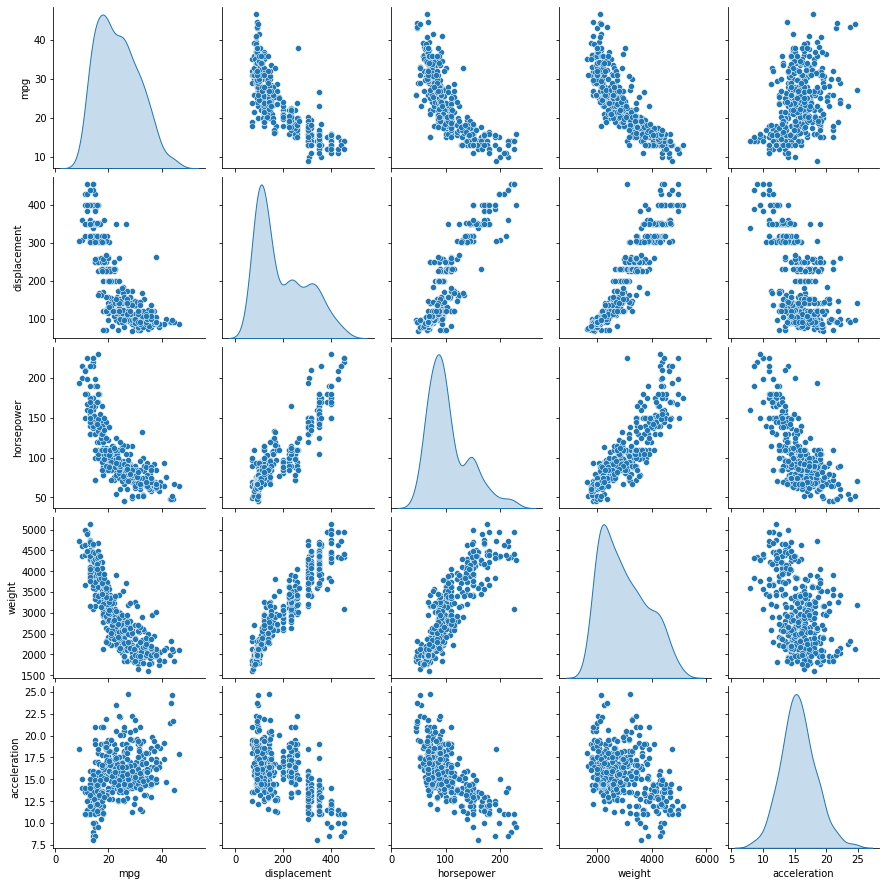

In [157]:
sns.pairplot(data[['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']], diag_kind = 'kde')
plt.show()

* **From the above plots it is observed that all the pairs of columns have high correlation between them and most of the columns are normally distributed.**

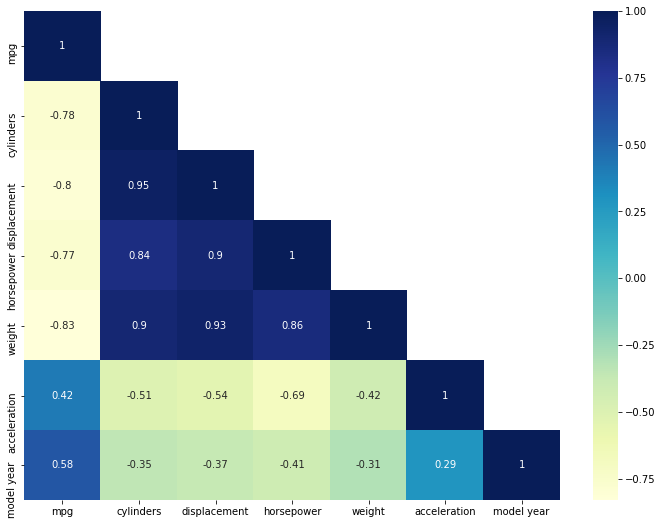

In [158]:
# heatmap to visualize the pearson's correlation matrix between the numeric variables
plt.figure(figsize = (12, 9))
sns.heatmap(data.corr(), annot = True, cmap = "YlGnBu", mask = np.triu(data.corr(), k = 1))
plt.show()

**From the above heatmap**

* Cylinders, Displacement, HorsePower, weight have **`high negative correlation`** with MPG

* Cylinders, Displacement, HorsePower, weight have **`high positive correlation`** between them

In [159]:
# The describe() method shows a summary of the nummerical attributes.
data.describe().T.round(decimals = 2)

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.51,7.82,9.0,17.50,23.0,29.00,46.6
cylinders,398.0,5.45,1.70,3.0,4.00,4.0,8.00,8.0
displacement,398.0,193.43,104.27,68.0,104.25,148.5,262.00,455.0
horsepower,398.0,104.30,38.22,46.0,76.00,93.5,125.00,230.0
weight,398.0,2970.42,846.84,1613.0,2223.75,2803.5,3608.00,5140.0
acceleration,398.0,15.57,2.76,8.0,13.82,15.5,17.17,24.8
model year,398.0,76.01,3.70,70.0,73.00,76.0,79.00,82.0


## Let's take a closer look at some of those graphs

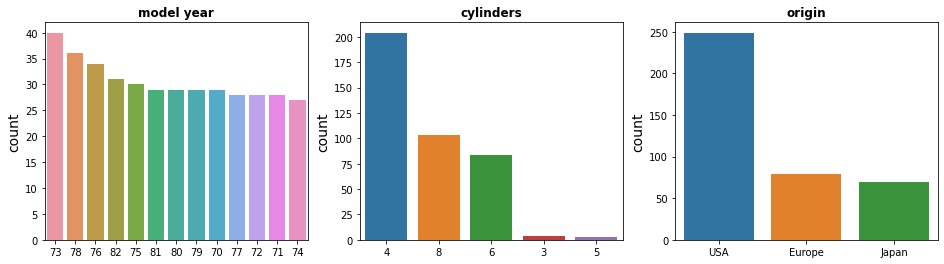

In [160]:
# Count plot for all discrete features
# Univariate Analysis

discrete_columns_list = ['model year', 'cylinders', 'origin']
plt.figure(figsize = (16, 4))
for i in range(len(discrete_columns_list)):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data[discrete_columns_list[i]], 
                  order = data[discrete_columns_list[i]].value_counts().index,)
    plt.title(discrete_columns_list[i], fontweight = "bold")
    plt.xlabel('')
    plt.ylabel('count', fontsize = 14)

**From the above visuals:**

* **`Cylinders`: Most of the automobiles contains 4 cylinders.**

* **`Model Year`: The number of cars manufactured in the year 1973.**

* **`Origin`: Most of the automobiles are manufactured in USA.**  

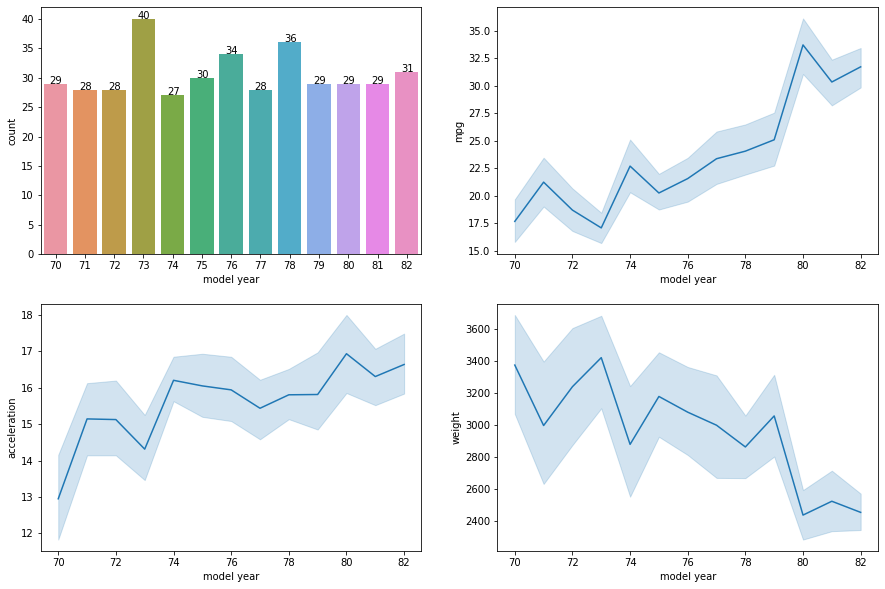

In [161]:
plt.figure(figsize = (15, 10))

plt.subplot(221)
ax = sns.countplot(data['model year'])

plt.subplot(222)
sns.lineplot(x = data['model year'], y = data['mpg'])

plt.subplot(223)
sns.lineplot(x = data['model year'], y = data['acceleration'])

plt.subplot(224)
sns.lineplot(x = data['model year'], y = data['weight'])

for i in ax.patches:
    ax.annotate('{}'.format(i.get_height()), (i.get_x()+0.2, i.get_height()))

* More number of car models were available during 1973 and 1978.

* From the lineplots, there is a sudden spike in the average milage, acceleration and decrease in the body weight in the year 1980, indicating shift in the auto-technology.

* There is a steady increase in the milage every year

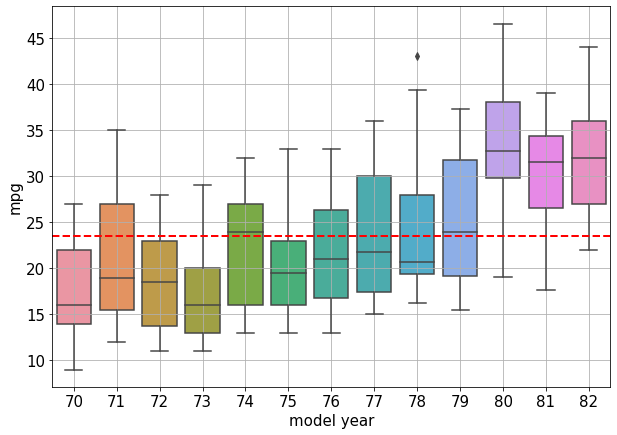

In [162]:
# Multivariate Analysis
plt.figure(figsize = (10, 7))
sns.boxplot(x = data['model year'], y = data['mpg'])
plt.axhline(data['mpg'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)
plt.xlabel('model year', fontsize = 15)
plt.ylabel('mpg', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True)
plt.show()

* With every year and with the newer models of the vehicles mileage per gallon (mpg) also increases.

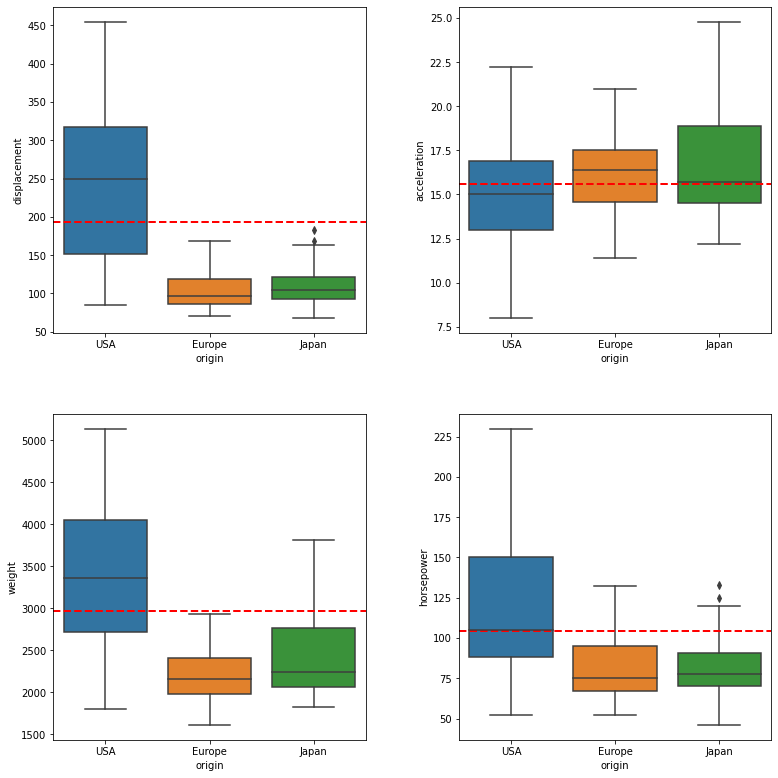

In [163]:
plt.figure(figsize = (12, 12))

plt.subplot(221)
sns.boxplot(x = data['origin'], y = data['displacement'])
plt.axhline(data['displacement'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)

plt.subplot(222)
sns.boxplot(x = data['origin'], y = data['acceleration'])
plt.axhline(data['acceleration'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)

plt.subplot(223)
sns.boxplot(x = data['origin'], y = data['weight'])
plt.axhline(data['weight'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)

plt.subplot(224)
sns.boxplot(x = data['origin'], y = data['horsepower'])
plt.axhline(data['horsepower'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)

plt.tight_layout(pad = 5)

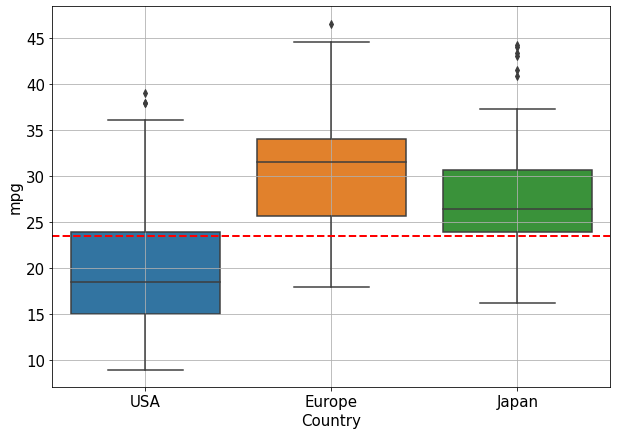

In [164]:
# Multivariate Analysis
fig, axes = plt.subplots(1, 1, figsize = (10, 7),)
sns.boxplot(x = data['origin'], y = data['mpg'])
plt.axhline(data['mpg'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)
plt.xlabel('Country', fontsize = 15)
plt.ylabel('mpg', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True)
plt.show()

The red line marks the  average of the set. From the above plot we can observe:

 - Majority of the cars from USA (almost 75%) have MPG below global average.
 - Majority of the cars from Japan and Europe have MPG above global average.

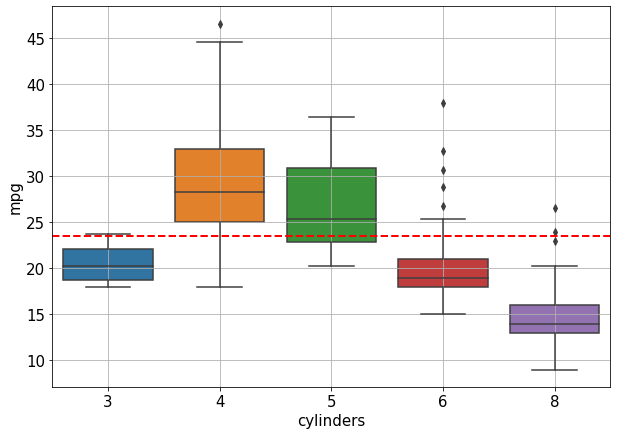

In [165]:
# Multivariate Analysis
plt.figure(figsize = (10, 7))
sns.boxplot(x = data['cylinders'], y = data['mpg'])
plt.axhline(data['mpg'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)
plt.xlabel('cylinders', fontsize = 15)
plt.ylabel('mpg', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True)
plt.show()

We can easily visualize that the mileage per gallon (mpg) of 4 cylinder vehicles is maximum and we also saw that most of the vehicles are 4 cylinder.
- From the above result we can carry out the inference that for most of the people **`mileage(mpg)`** is one of the major factor while buying a vehicle.|

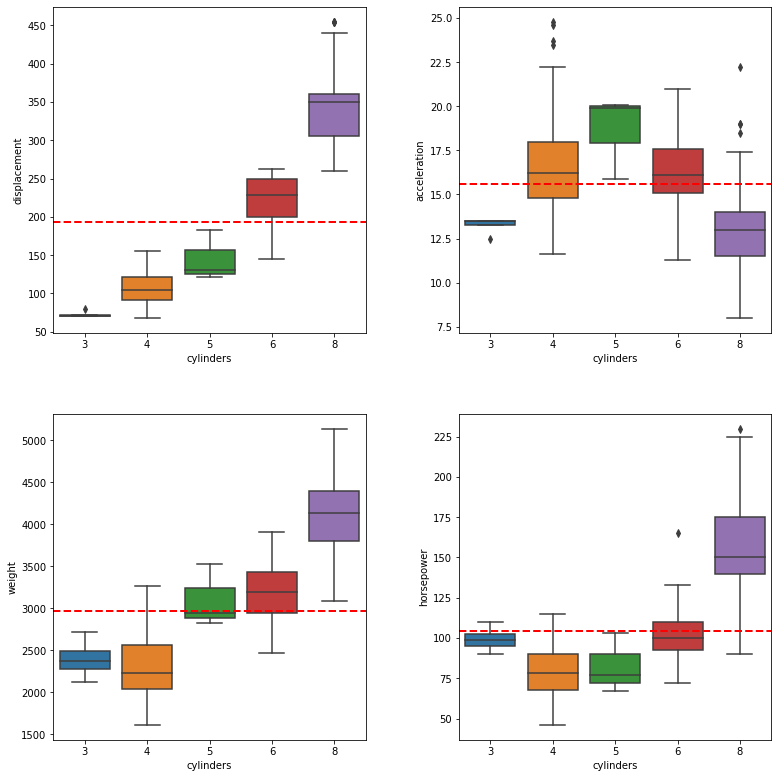

In [166]:
plt.figure(figsize = (12, 12))

plt.subplot(221)
sns.boxplot(x = data['cylinders'], y = data['displacement'])
plt.axhline(data['displacement'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)

plt.subplot(222)
sns.boxplot(x = data['cylinders'], y = data['acceleration'])
plt.axhline(data['acceleration'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)

plt.subplot(223)
sns.boxplot(x = data['cylinders'], y = data['weight'])
plt.axhline(data['weight'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)

plt.subplot(224)
sns.boxplot(x = data['cylinders'], y = data['horsepower'])
plt.axhline(data['horsepower'].mean(), color = 'r', linestyle = 'dashed', linewidth = 2)

plt.tight_layout(pad = 5)

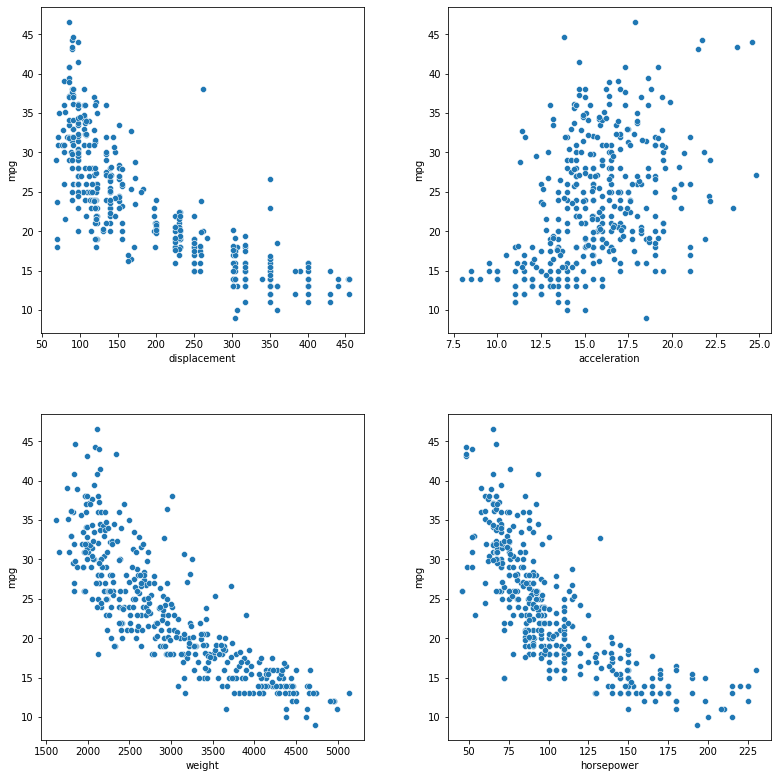

In [167]:
plt.figure(figsize = (12, 12))

plt.subplot(221)
sns.scatterplot(x = data['displacement'], y = data['mpg'])

plt.subplot(222)
sns.scatterplot(x = data['acceleration'], y = data['mpg'])

plt.subplot(223)
sns.scatterplot(x = data['weight'], y = data['mpg'])

plt.subplot(224)
sns.scatterplot(x = data['horsepower'], y = data['mpg'])

plt.tight_layout(pad = 5)

* Milage has a strong negative correlation with displacement, weight and horsepower.

* Acceleration has slight positive correlation.

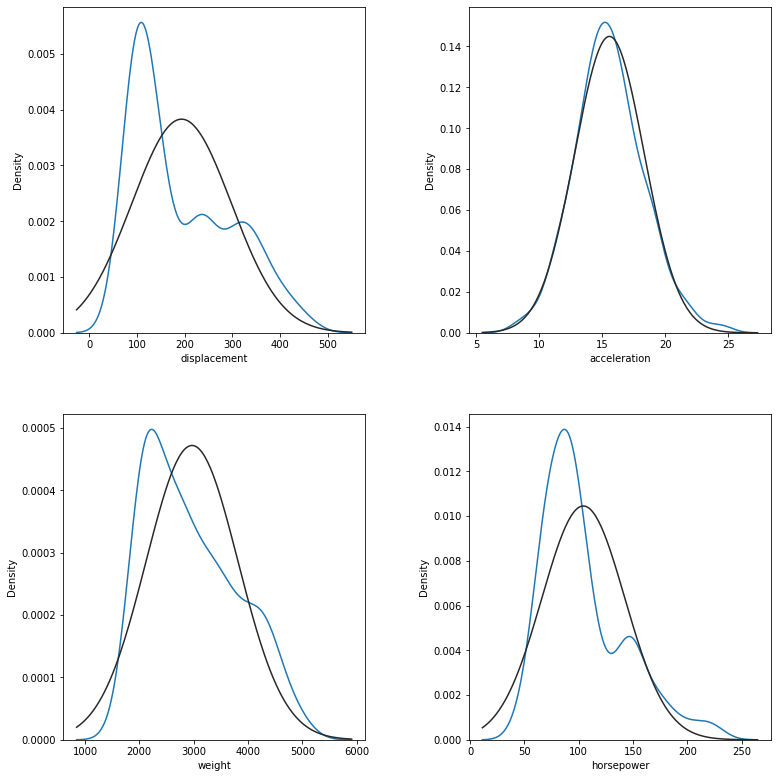

In [168]:
plt.figure(figsize = (12, 12))

plt.subplot(221)
sns.distplot(data['displacement'], fit = stats.norm, hist = False)

plt.subplot(222)
sns.distplot(data['acceleration'],fit = stats.norm, hist = False)

plt.subplot(223)
sns.distplot(data['weight'], fit = stats.norm, hist = False)

plt.subplot(224)
sns.distplot(data['horsepower'], fit = stats.norm, hist = False)

plt.tight_layout(pad = 5)

* Horsepower, displacement, weight are right skewed. Whereas, acceleration is normally distributed.

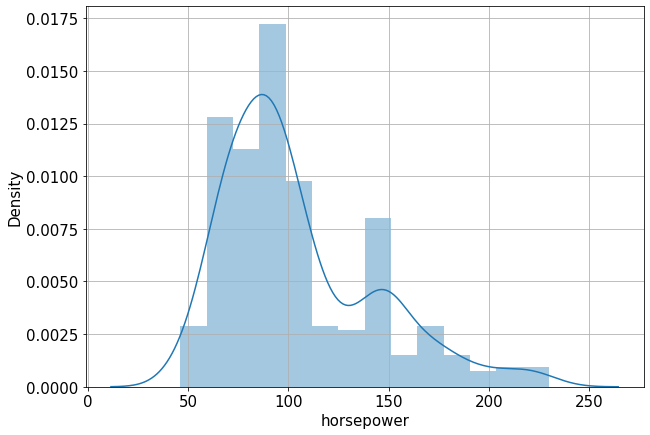

In [169]:
# Univariate Analysis
plt.figure(figsize = (10, 7))
sns.distplot(data['horsepower'])
plt.xlabel('horsepower', fontsize = 15)
plt.ylabel('Density', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True)
plt.show()

1. Horsepower rates the engine performance of cars
2. From the above plot we can see the distribution of the horsepower of the vehicles.
3. We can visualize that most of the vehicles have around **75-110 horsepower** and only few vehicles have horsepoer above 200.

In [170]:
print("Skewness: %f" % data['horsepower'].skew())
print("Kurtosis: %f" % data['horsepower'].kurt())

Skewness: 1.106224
Kurtosis: 0.763583


**Engine displacement** is the swept volume of all the pistons inside the cylinders of a reciprocating engine in a single movement from top dead centre (TDC) to bottom dead centre (BDC).

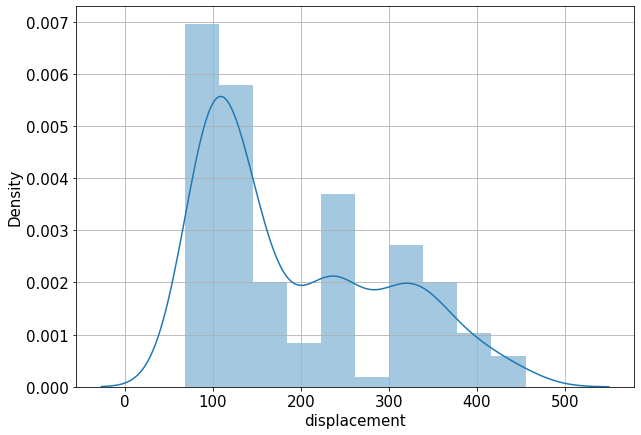

In [171]:
# Univariate Analysis
plt.figure(figsize = (10, 7))
sns.distplot(data['displacement'])
plt.xlabel('displacement', fontsize = 15)
plt.ylabel('Density', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.grid(True)
plt.show()

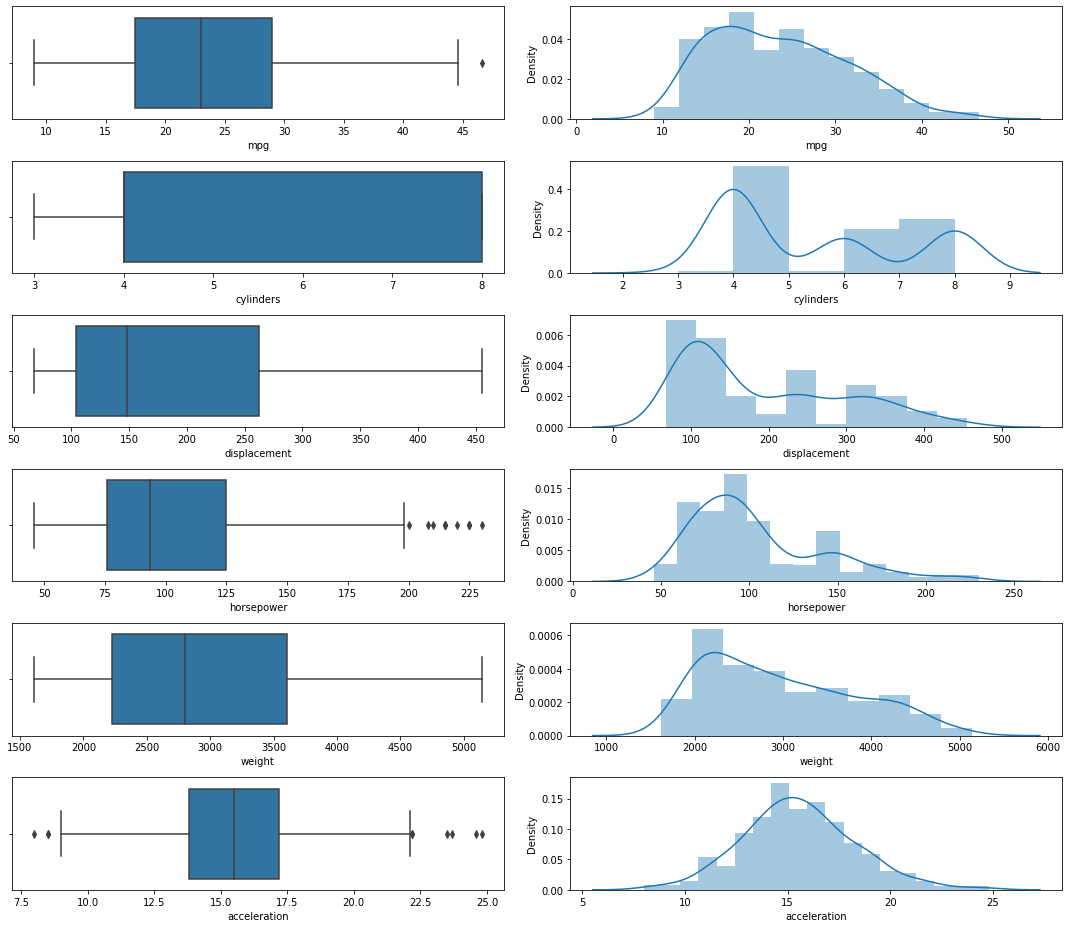

In [172]:
# Exploring the range and distribution of numerical Variables 
# Plotting box plot to check the outliers

fig, ax = plt.subplots(6, 2, figsize = (15, 13))
sns.boxplot(x = data["mpg"], ax = ax[0,0])
sns.distplot(data['mpg'], ax = ax[0,1])

sns.boxplot(x = data["cylinders"], ax = ax[1,0])
sns.distplot(data['cylinders'], ax = ax[1,1])

sns.boxplot(x = data["displacement"], ax = ax[2,0])
sns.distplot(data['displacement'], ax = ax[2,1])

sns.boxplot(x = data["horsepower"], ax = ax[3,0])
sns.distplot(data['horsepower'], ax = ax[3,1])

sns.boxplot(x = data["weight"], ax = ax[4,0])
sns.distplot(data['weight'], ax = ax[4,1])

sns.boxplot(x = data["acceleration"], ax = ax[5,0])
sns.distplot(data['acceleration'], ax = ax[5,1])

plt.tight_layout()

* **There are very few ouliers present in the dataset which are very nearer to upper boundary. So, there is no need of outliers treatment.**

## Weight vs. Horsepower

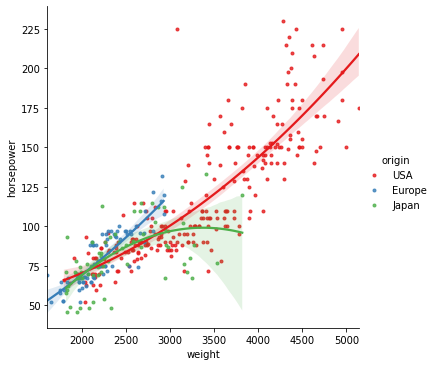

In [173]:
sns.lmplot(x = 'weight', y = 'horsepower', data = data, order = 2, hue = 'origin', palette = 'Set1', markers = [".", ".", "."])
plt.show()

**USA automobiles seem to have higher horsepower at a given weight**

We can also group the linear regressions by row or column instead of overlaying them in the same plot by passing the argument row = 'categorical variable' or col = 'categorical variable'.

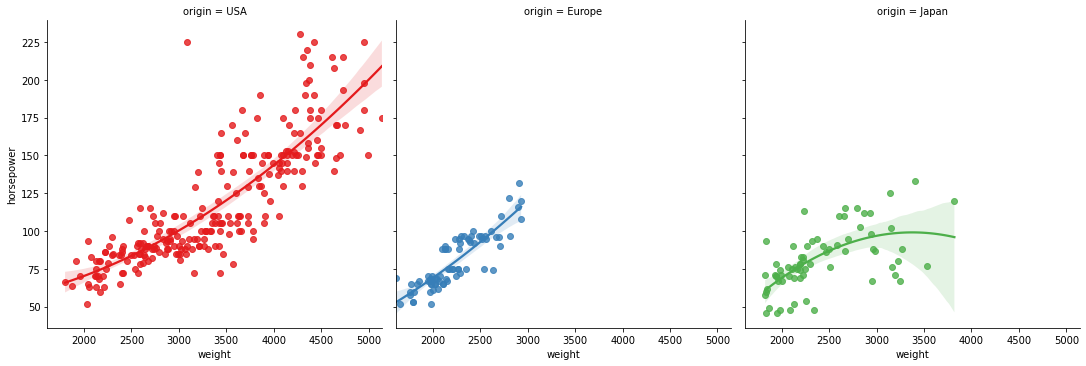

In [174]:
sns.lmplot(x = 'weight', y = 'horsepower', col = 'origin', data = data, order = 2, hue = 'origin', palette = 'Set1')
plt.show()

## Horsepower vs. mpg

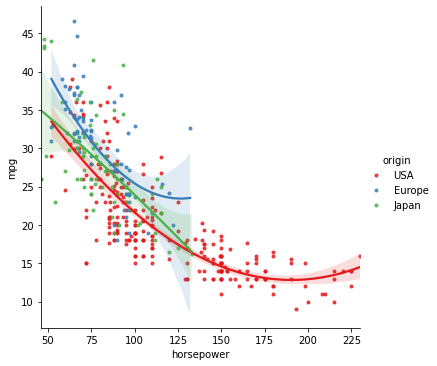

In [175]:
sns.lmplot(x = 'horsepower', y = 'mpg', data = data, order = 2, hue = 'origin', palette = 'Set1', markers = [".", ".", "."])
plt.show()

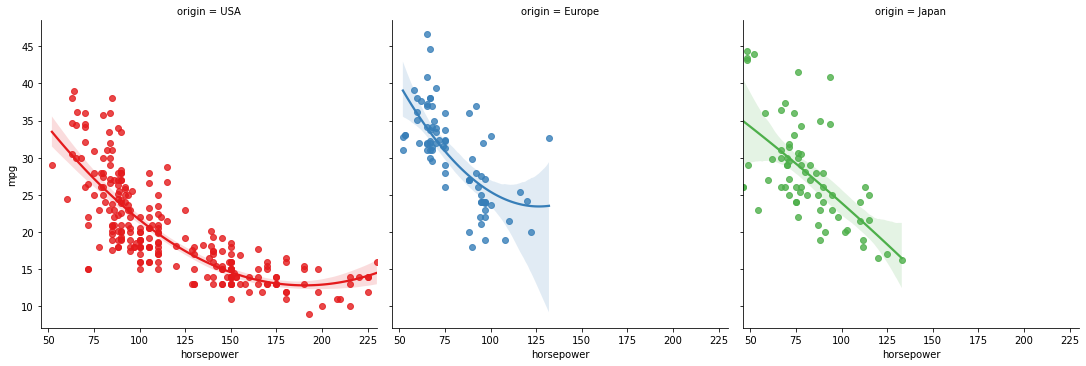

In [176]:
sns.lmplot(x = 'horsepower', y = 'mpg', col = 'origin', data = data, order = 2, hue = 'origin', palette = 'Set1')
plt.show()

## Displacement vs. mpg

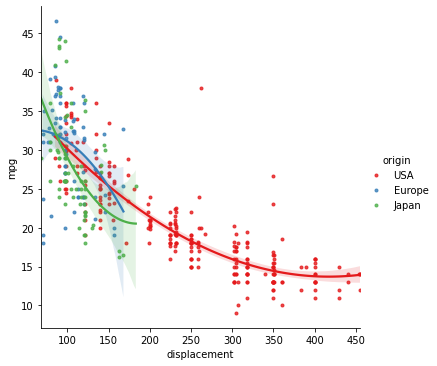

In [177]:
sns.lmplot(x = 'displacement', y = 'mpg', data = data, order = 2, hue = 'origin', palette = 'Set1', markers = [".", ".", "."])
plt.show()

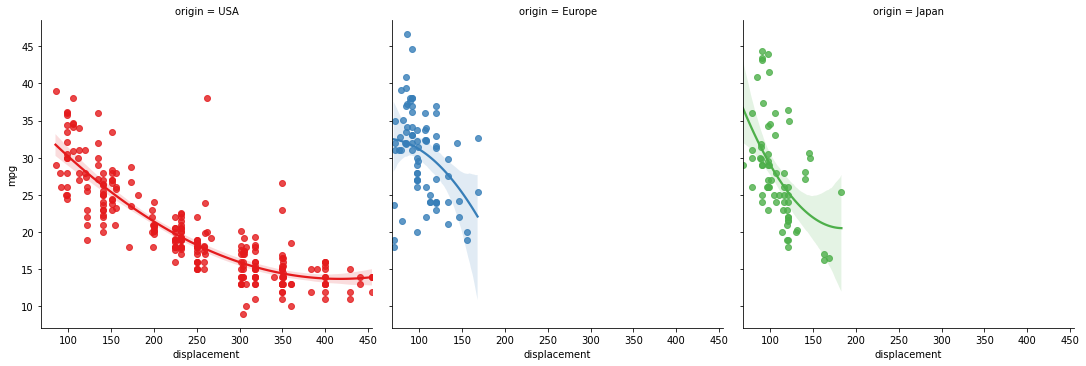

In [178]:
sns.lmplot(x = 'displacement', y = 'mpg', col = 'origin', data = data, order = 2, hue = 'origin', palette = 'Set1')
plt.show()

## Weight vs. mpg

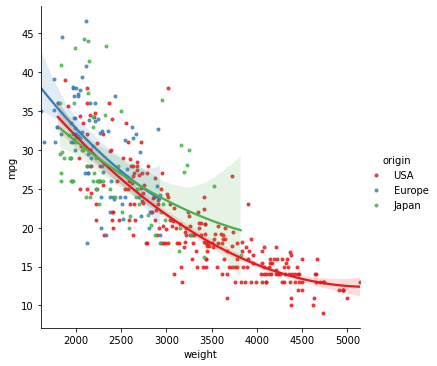

In [179]:
sns.lmplot(x = 'weight', y = 'mpg', data = data, order = 2, hue = 'origin', palette = 'Set1', markers = [".", ".", "."])
plt.show()

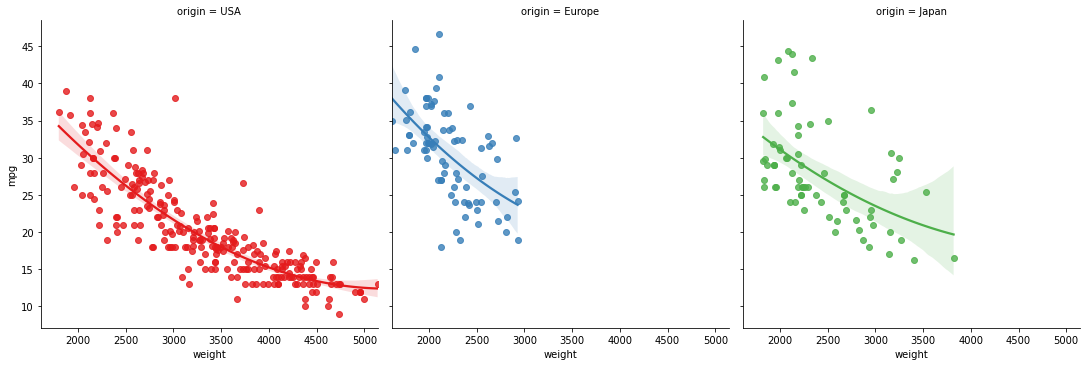

In [180]:
sns.lmplot(x = 'weight', y = 'mpg', col = 'origin', data = data, order = 2, hue = 'origin', palette = 'Set1')
plt.show()

## Weight vs. acceleration

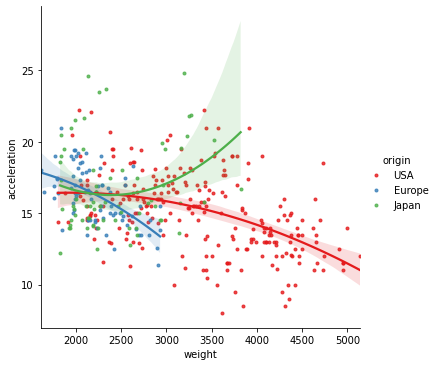

In [181]:
sns.lmplot(x = 'weight', y = 'acceleration', data = data, order = 2, hue = 'origin', palette = 'Set1', markers = [".", ".", "."])
plt.show()

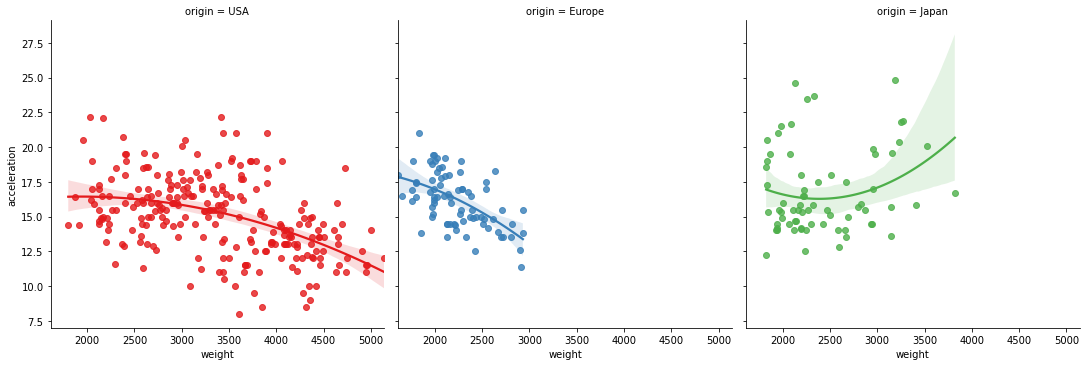

In [182]:
sns.lmplot(x = 'weight', y = 'acceleration', col = 'origin', data = data, order = 2, hue = 'origin', palette = 'Set1')
plt.show()

## Acceleration vs. mpg

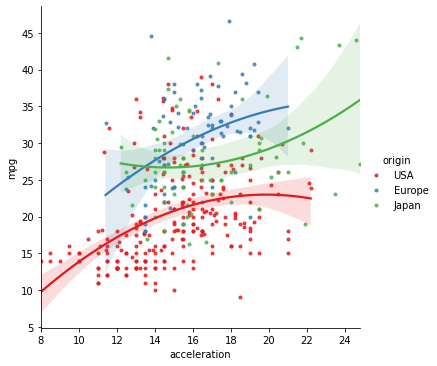

In [183]:
sns.lmplot(x = 'acceleration', y = 'mpg', data = data, order = 2, hue = 'origin', palette = 'Set1', markers = [".", ".", "."])
plt.show()

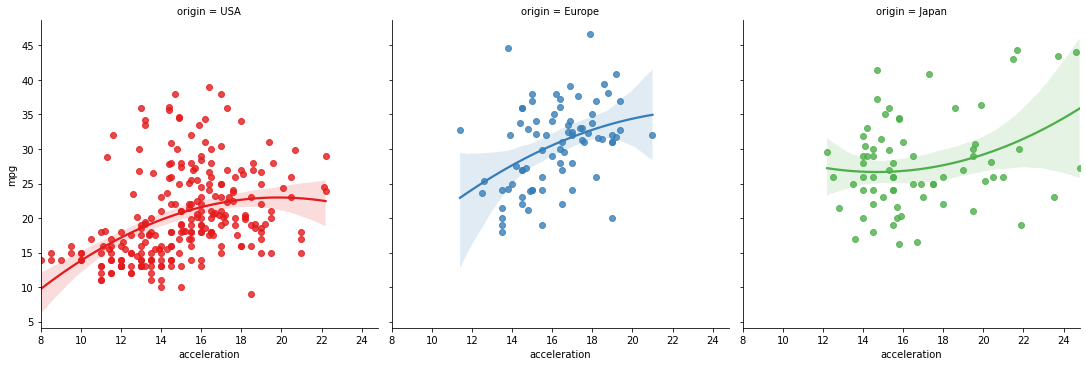

In [184]:
sns.lmplot(x = 'acceleration', y = 'mpg', col = 'origin', data = data, order = 2, hue = 'origin', palette = 'Set1')
plt.show()

## Model Year vs. Displacement

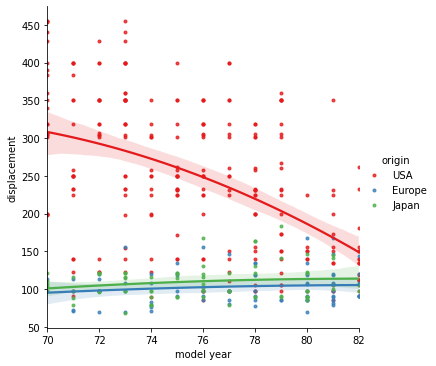

In [185]:
sns.lmplot(x = 'model year', y = 'displacement', data = data, order = 2, hue = 'origin', palette = 'Set1', markers = [".", ".", "."])
plt.show()

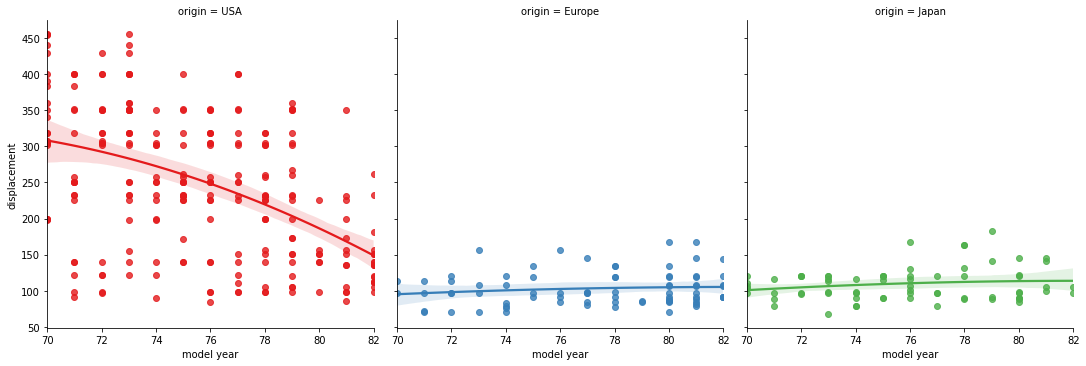

In [186]:
sns.lmplot(x = 'model year', y = 'displacement', col = 'origin', data = data, order = 2, hue = 'origin', palette = 'Set1')
plt.show()

In [187]:
# Copy dataframe to save progress at this checkpoint
checkpoint2 = data.copy(deep = True)

In [188]:
# Load this cell instead of starting from beginning
data = checkpoint2.copy(deep = True)

We cannot use feature 'origin' as is, because the values are numerical but categorical(biased), so we need to create dummy variables.

I will be applying One Hot Encoding for **origin** and **cylinders** because these features have categorical values.

### Convert catrgorical features to numeric

In [189]:
data['origin'] = data['origin'].astype(str) 
data['cylinders'] = data['cylinders'].astype(str)
data['model year'] = data['model year'].astype(str)

In [190]:
# Basic description of the numerical variables
data.describe(include = "O").T

,count,unique,top,freq
cylinders,398,5,4,204
model year,398,13,73,40
origin,398,3,USA,249


In [191]:
data = pd.get_dummies(data, columns = ['origin'])
data = pd.get_dummies(data, columns = ['cylinders'])
data = pd.get_dummies(data, columns = ['model year'])

In [192]:
data.head()

,mpg,displacement,horsepower,weight,acceleration,origin_Europe,origin_Japan,origin_USA,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,model year_70,model year_71,model year_72,model year_73,model year_74,model year_75,model year_76,model year_77,model year_78,model year_79,model year_80,model year_81,model year_82
0,18.0,307.0,130.0,3504,12.0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
1,15.0,350.0,165.0,3693,11.5,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,18.0,318.0,150.0,3436,11.0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
3,16.0,304.0,150.0,3433,12.0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
4,17.0,302.0,140.0,3449,10.5,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0


In [193]:
data.dtypes

mpg              float64
displacement     float64
horsepower       float64
weight             int64
acceleration     float64
origin_Europe      uint8
origin_Japan       uint8
origin_USA         uint8
cylinders_3        uint8
cylinders_4        uint8
cylinders_5        uint8
cylinders_6        uint8
cylinders_8        uint8
model year_70      uint8
model year_71      uint8
model year_72      uint8
model year_73      uint8
model year_74      uint8
model year_75      uint8
model year_76      uint8
model year_77      uint8
model year_78      uint8
model year_79      uint8
model year_80      uint8
model year_81      uint8
model year_82      uint8
dtype: object

In [194]:
# Basic description of the numerical variables
data.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,398.0,104.304020,38.222625,46.0,76.000,93.5,125.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
origin_Europe,398.0,0.198492,0.399367,0.0,0.000,0.0,0.000,1.0
origin_Japan,398.0,0.175879,0.381197,0.0,0.000,0.0,0.000,1.0
origin_USA,398.0,0.625628,0.484569,0.0,0.000,1.0,1.000,1.0
cylinders_3,398.0,0.010050,0.099871,0.0,0.000,0.0,0.000,1.0
cylinders_4,398.0,0.512563,0.500471,0.0,0.000,1.0,1.000,1.0


* **Numerical Variables**: MPG, Displacement, Horsepower, and Acceleration

  Note: Horsepower is continous variable which is wrongly taken as discrete variable

* **Catergorical Variables**: Cylinders, Model Year, Origin

<a id = "2"></a><br>
# Train Test Split & Standardization

In [195]:
# Converting data into dependent and independent variable 

# X is our feature data
# y is our target variable

X = data.drop(['mpg'], axis = 1)
y = data['mpg']

print("Shape of X :", X.shape)
print('Shape of y :', y.shape)

Shape of X : (398, 25)
Shape of y : (398,)


In [196]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

print("Shape of x_train : ", X_train.shape)
print("Shape of y_train : ", y_train.shape)

print("\nShape of x_test : ", X_test.shape)
print("Shape of y_test : ", y_test.shape)

Shape of x_train :  (318, 25)
Shape of y_train :  (318,)

Shape of x_test :  (80, 25)
Shape of y_test :  (80,)


## Standardization

In [199]:
scaler = RobustScaler()
scaler.fit(X_train)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train)

[[ 1.05772231  1.13        0.97583643 ...  0.          0.
   0.        ]
 [-0.32137285 -0.67       -0.73494424 ...  0.          0.
   0.        ]
 [-0.32137285 -0.31       -0.47174721 ...  1.          0.
   0.        ]
 ...
 [-0.50234009 -0.89       -0.71040892 ...  0.          0.
   0.        ]
 [ 0.63338534  0.13        0.34163569 ...  0.          0.
   0.        ]
 [-0.3650546  -0.45       -0.44572491 ...  0.          0.
   0.        ]]


In [200]:
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns = data.columns)

Text(0.5, 1.0, 'Before Standardization')

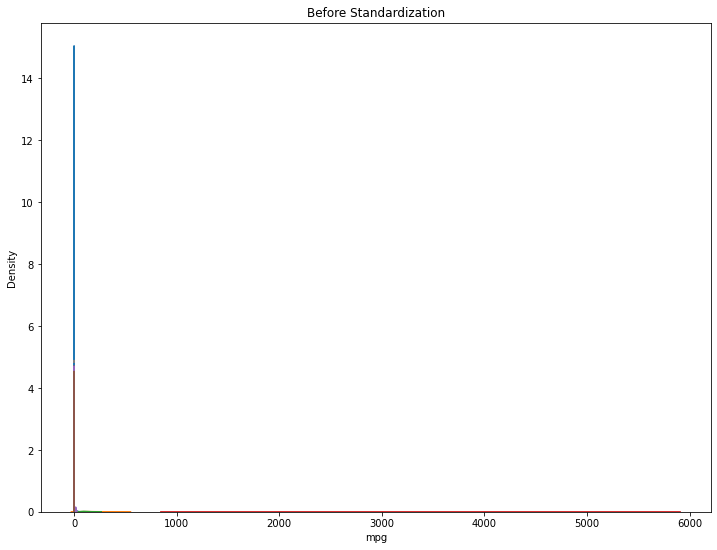

In [201]:
plt.figure(figsize = (12, 9))

for col in data.columns:
    sns.kdeplot(data[col])

plt.title('Before Standardization')

Text(0.5, 1.0, 'After Standardization')

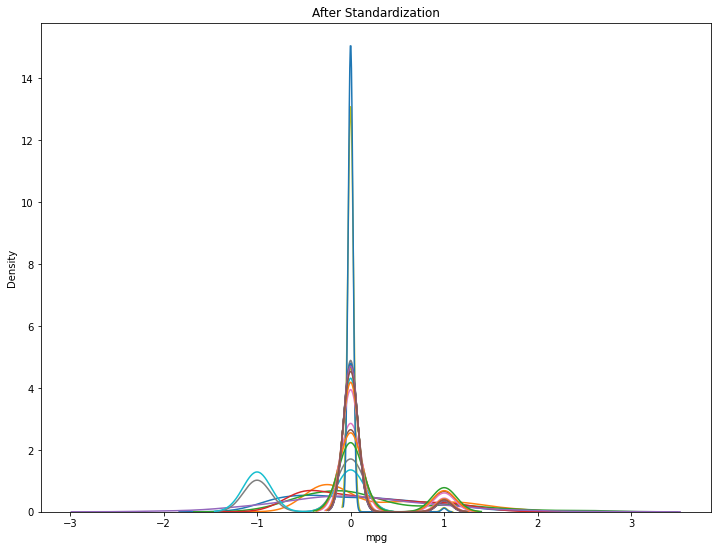

In [202]:
plt.figure(figsize = (12, 9))

for col in data_scaled.columns:
    sns.kdeplot(data_scaled[col])

plt.title('After Standardization')

<a id = "2"></a><br>
# Linear Regression

In [203]:
LR = LinearRegression()
LR.fit(X_train, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [204]:
LR_pred = LR.predict(X_test)
print("Linear Regression intercept:", LR.intercept_)
print("Linear Regression coef:", LR.coef_)

Linear Regression intercept: 23.548999393022804
Linear Regression coef: [ 2.325743   -1.80453154 -7.54720899  0.39560761  1.10010987  0.50911149
 -1.60922136 -4.21273351  1.4515368   1.64723102 -0.57126656  1.68523226
 -3.15095236 -2.05637288 -2.85698341 -3.49262864 -1.63654836 -1.75006649
 -1.59669808  0.43096855 -0.16416034  1.36426996  5.80114709  4.28597068
  4.82205428]


In [205]:
LR_mse = mean_squared_error(y_test, LR_pred)
print("Linear Regression MSE:", LR_mse)

Linear Regression MSE: 7.870627581657018


In [206]:
LR_score = LR.score(X_train, y_train)
LR_score*100

86.79747265264214

In [207]:
LR_r2score = r2_score(y_test, LR_pred)
LR_r2score*100

87.59698524929999

In [208]:
print('Accuracy of Linear Regression on train set: {:.4f}'.format(LR.score(X_train, y_train)*100))

Accuracy of Linear Regression on train set: 86.7975


In [209]:
print('Accuracy of Linear Regression on test set: {:.4f}'.format(LR.score(X_test, y_test)*100))

Accuracy of Linear Regression on test set: 87.5970


In [210]:
cv_rmse = cross_val_score(LR, X_train, y_train, cv = 3, scoring = 'neg_mean_squared_error')
print("Mean of cv rmse's:", np.mean(np.sqrt(np.abs(cv_rmse))))
print("Variance of cv rmse's:", np.std(np.sqrt(np.abs(cv_rmse)), ddof = 1))

Mean of cv rmse's: 2.946630738523743
Variance of cv rmse's: 0.3814187879278986


Text(0.5, 0, 'MPG')

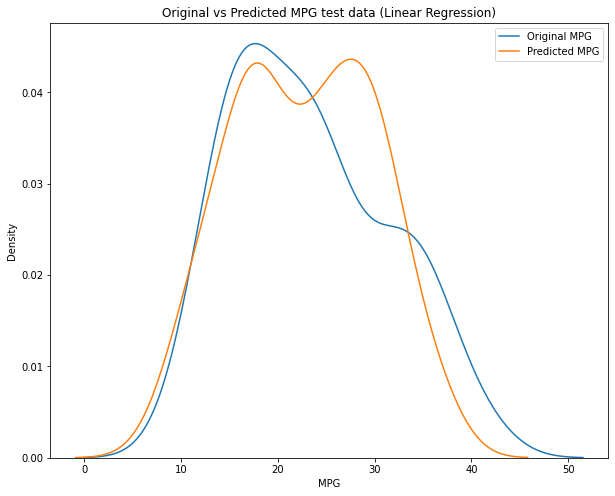

In [229]:
plt.figure(figsize = (10, 8))
sns.distplot(y_test, hist = False, label = "Original MPG")
sns.distplot(LR_pred, hist = False, label = "Predicted MPG")
plt.title("Original vs Predicted MPG test data (Linear Regression)")
plt.legend()
plt.xlabel("MPG")

<a id = "2"></a><br>
# Support Vector Regression

In [231]:
SVM = SVR(kernel = 'linear')
SVM.fit(X_train, y_train)

SVR(C=1.0, cache_size=200, coef0=0.0, degree=3, epsilon=0.1, gamma='scale',
    kernel='linear', max_iter=-1, shrinking=True, tol=0.001, verbose=False)

In [232]:
SVR_pred = SVM.predict(X_test)
print("Support Vector Regressor intercept:", SVM.intercept_)
print("Support Vector Regressor coef:", SVM.coef_)

Support Vector Regressor intercept: [24.41639676]
Support Vector Regressor coef: [[ 0.58910834 -2.45386715 -4.6590622  -0.15703662  1.13980755  0.
  -1.13980755 -2.49620139  2.00720578  1.         -1.1528387   0.64183431
  -1.75411158 -1.75408066 -2.32939735 -2.64464089 -1.38131822 -0.83590995
  -0.8990674   0.01455539 -0.02622398  1.29098839  3.67048839  3.58763747
   3.06108038]]


In [233]:
SVR_mse = mean_squared_error(y_test, SVR_pred)
print("Support Vector Regression MSE:", SVR_mse)

Support Vector Regression MSE: 9.331256965748556


In [234]:
SVR_score = SVM.score(X_train, y_train)
SVR_score*100

84.58411320077427

In [235]:
SVR_r2score = r2_score(y_test, SVR_pred)
SVR_r2score*100

85.29523642327065

In [236]:
print('Accuracy of Support Vector Regression on train set: {:.4f}'.format(SVM.score(X_train, y_train)*100))

Accuracy of Support Vector Regression on train set: 84.5841


In [237]:
print('Accuracy of Support Vector Regression on test set: {:.4f}'.format(SVM.score(X_test, y_test)*100))

Accuracy of Support Vector Regression on test set: 85.2952


In [238]:
cv_rmse = cross_val_score(SVM, X_train, y_train, cv = 3, scoring = 'neg_mean_squared_error')
print("Mean of cv rmse's:", np.mean(np.sqrt(np.abs(cv_rmse))))
print("Variance of cv rmse's:", np.std(np.sqrt(np.abs(cv_rmse)), ddof = 1))

Mean of cv rmse's: 3.1822017623804766
Variance of cv rmse's: 0.5231767872404759


Text(0.5, 0, 'MPG')

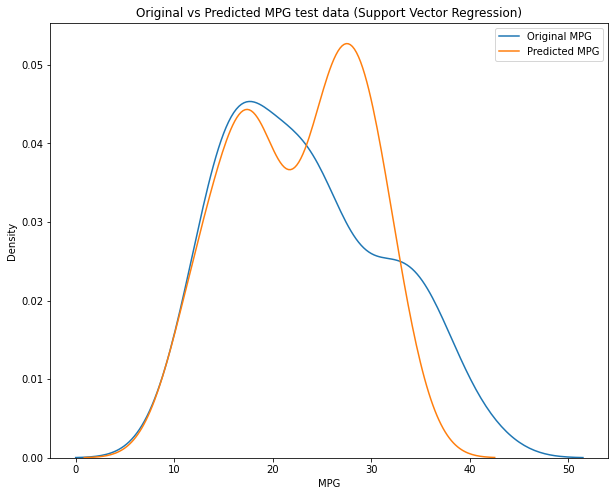

In [239]:
plt.figure(figsize = (10, 8))
sns.distplot(y_test, hist = False, label = "Original MPG")
sns.distplot(SVR_pred, hist = False, label = "Predicted MPG")
plt.title("Original vs Predicted MPG test data (Support Vector Regression)")
plt.legend()
plt.xlabel("MPG")

<a id = "2"></a><br>
# Random Forest Regressor

In [240]:
RFG = RandomForestRegressor(criterion = 'mse', n_estimators = 100, random_state = 0)
RFG.fit(X_train, y_train)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=0, verbose=0, warm_start=False)

In [241]:
RFG_pred = RFG.predict(X_test)

In [242]:
RFG_mse = mean_squared_error(y_test, RFG_pred)
print("Random Forest Regression MSE:", RFG_mse)

Random Forest Regression MSE: 12.711541037500007


In [243]:
RFG_score = RFG.score(X_train, y_train)
RFG_score*100

97.46153253203713

In [244]:
RFG_r2score = r2_score(y_test, RFG_pred)
RFG_r2score*100

79.96837871484598

In [245]:
print('Accuracy of Random Forest Regressor on train set: {:.4f}'.format(RFG.score(X_train, y_train)*100))

Accuracy of Random Forest Regressor on train set: 97.4615


In [246]:
print('Accuracy of Random Forest Regressor on test set: {:.4f}'.format(RFG.score(X_test, y_test)*100))

Accuracy of Random Forest Regressor on test set: 79.9684


In [247]:
cv_rmse = cross_val_score(RFG, X_train, y_train, cv = 3, scoring = 'neg_mean_squared_error')
print("Mean of cv rmse's:", np.mean(np.sqrt(np.abs(cv_rmse))))
print("Variance of cv rmse's:", np.std(np.sqrt(np.abs(cv_rmse)), ddof = 1))

Mean of cv rmse's: 3.3211672658258773
Variance of cv rmse's: 0.4327915942826372


Text(0.5, 0, 'MPG')

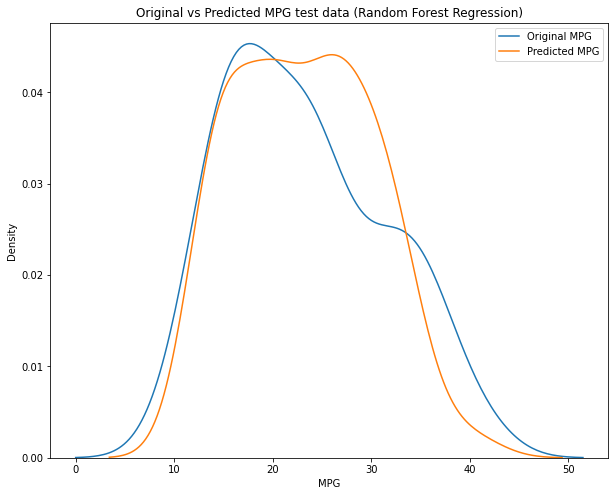

In [248]:
plt.figure(figsize = (10, 8))
sns.distplot(y_test, hist = False, label = "Original MPG")
sns.distplot(RFG_pred, hist = False, label = "Predicted MPG")
plt.title("Original vs Predicted MPG test data (Random Forest Regression)")
plt.legend()
plt.xlabel("MPG")

<a id = "2"></a><br>
# Decision Tree Regressor

In [249]:
DTR = DecisionTreeRegressor(criterion = 'friedman_mse', splitter = 'random', random_state = 0)
DTR.fit(X_train, y_train)

DecisionTreeRegressor(ccp_alpha=0.0, criterion='friedman_mse', max_depth=None,
                      max_features=None, max_leaf_nodes=None,
                      min_impurity_decrease=0.0, min_impurity_split=None,
                      min_samples_leaf=1, min_samples_split=2,
                      min_weight_fraction_leaf=0.0, presort='deprecated',
                      random_state=0, splitter='random')

In [250]:
DTR_pred = DTR.predict(X_test)

In [251]:
DTR_mse = mean_squared_error(y_test, DTR_pred)
print("Decision Tree Regression MSE:", DTR_mse)

Decision Tree Regression MSE: 15.755875


In [252]:
DTR_score = DTR.score(X_train, y_train)
DTR_score*100

100.0

In [253]:
DTR_r2score = r2_score(y_test, DTR_pred)
DTR_r2score*100

75.17093166869887

In [254]:
print('Accuracy of Decision Tree Regressor on train set: {:.4f}'.format(DTR.score(X_train, y_train)*100))

Accuracy of Decision Tree Regressor on train set: 100.0000


In [255]:
print('Accuracy of Decision Tree Regressor on test set: {:.4f}'.format(DTR.score(X_test, y_test)*100))

Accuracy of Decision Tree Regressor on test set: 75.1709


In [256]:
cv_rmse = cross_val_score(DTR, X_train, y_train, cv = 3, scoring = 'neg_mean_squared_error')
print("Mean of cv rmse's:", np.mean(np.sqrt(np.abs(cv_rmse))))
print("Variance of cv rmse's:", np.std(np.sqrt(np.abs(cv_rmse)), ddof = 1))

Mean of cv rmse's: 4.365329483212294
Variance of cv rmse's: 0.43923026557187733


Text(0.5, 0, 'MPG')

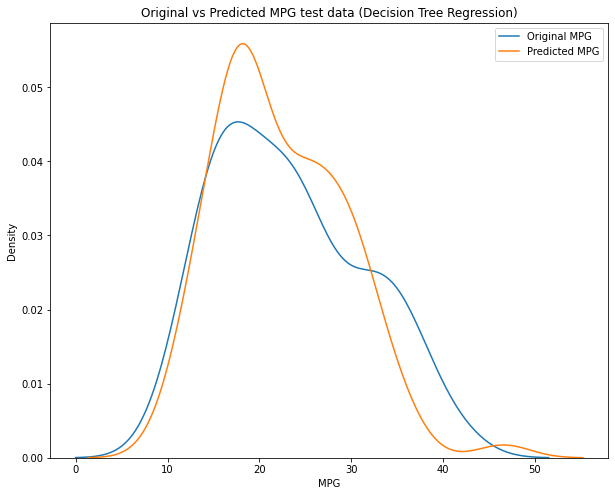

In [257]:
plt.figure(figsize = (10, 8))
sns.distplot(y_test, hist = False, label = "Original MPG")
sns.distplot(DTR_pred, hist = False, label = "Predicted MPG")
plt.title("Original vs Predicted MPG test data (Decision Tree Regression)")
plt.legend()
plt.xlabel("MPG")

<a id = "2"></a><br>
# KNeighbors Regressor

In [258]:
KNR = KNeighborsRegressor(n_neighbors = 6, algorithm = 'auto')
KNR.fit(X_train, y_train)

KNeighborsRegressor(algorithm='auto', leaf_size=30, metric='minkowski',
                    metric_params=None, n_jobs=None, n_neighbors=6, p=2,
                    weights='uniform')

In [259]:
KNR_pred = KNR.predict(X_test)

In [260]:
KNR_mse = mean_squared_error(y_test, KNR_pred)
print("KNeighbors Regression MSE:", KNR_mse)

KNeighbors Regression MSE: 12.322118055555553


In [261]:
KNR_score = KNR.score(X_train, y_train)
KNR_score*100

85.73056807762252

In [262]:
KNR_r2score = r2_score(y_test, KNR_pred)
KNR_r2score*100

80.58205518971506

In [263]:
print('Accuracy of KNeighbors Regression on train set: {:.4f}'.format(KNR.score(X_train, y_train)*100))

Accuracy of KNeighbors Regression on train set: 85.7306


In [264]:
print('Accuracy of KNeighbors Regression on test set: {:.4f}'.format(KNR.score(X_test, y_test)*100))

Accuracy of KNeighbors Regression on test set: 80.5821


In [265]:
cv_rmse = cross_val_score(KNR, X_train, y_train, cv = 3, scoring = 'neg_mean_squared_error')
print("Mean of cv rmse's:", np.mean(np.sqrt(np.abs(cv_rmse))))
print("Variance of cv rmse's:", np.std(np.sqrt(np.abs(cv_rmse)), ddof = 1))

Mean of cv rmse's: 3.4966317873726744
Variance of cv rmse's: 0.3920253294218884


Text(0.5, 0, 'MPG')

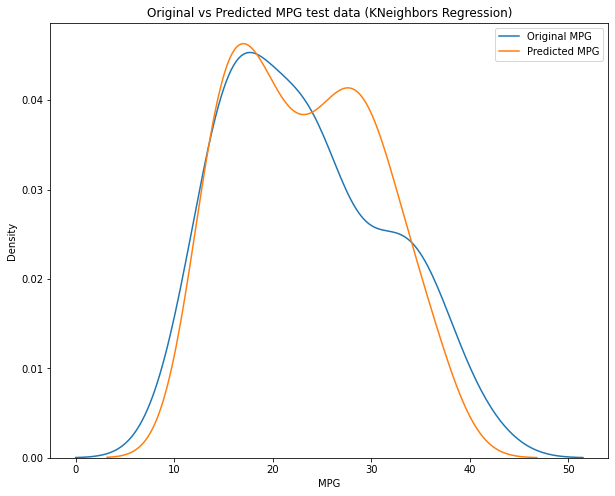

In [266]:
plt.figure(figsize = (10, 8))
sns.distplot(y_test, hist = False, label = "Original MPG")
sns.distplot(KNR_pred, hist = False, label = "Predicted MPG")
plt.title("Original vs Predicted MPG test data (KNeighbors Regression)")
plt.legend()
plt.xlabel("MPG")

<a id = "2"></a><br>
# Gradient Boosting Regressor

In [267]:
GBR = GradientBoostingRegressor(n_estimators = 4000, loss = 'ls', criterion = 'friedman_mse', random_state = 0)
GBR.fit(X_train, y_train)

GradientBoostingRegressor(alpha=0.9, ccp_alpha=0.0, criterion='friedman_mse',
                          init=None, learning_rate=0.1, loss='ls', max_depth=3,
                          max_features=None, max_leaf_nodes=None,
                          min_impurity_decrease=0.0, min_impurity_split=None,
                          min_samples_leaf=1, min_samples_split=2,
                          min_weight_fraction_leaf=0.0, n_estimators=4000,
                          n_iter_no_change=None, presort='deprecated',
                          random_state=0, subsample=1.0, tol=0.0001,
                          validation_fraction=0.1, verbose=0, warm_start=False)

In [268]:
GBR_pred = GBR.predict(X_test)

In [269]:
GBR_mse = mean_squared_error(y_test, GBR_pred)
print("Gradient Boosting Regression MSE:", GBR_mse)

Gradient Boosting Regression MSE: 10.482168173204471


In [270]:
GBR_score = GBR.score(X_train, y_train)
GBR_score*100

99.99999983422455

In [271]:
GBR_r2score = r2_score(y_test, GBR_pred)
GBR_r2score*100

83.48156038095735

In [272]:
print('Accuracy of ElasticNet Regression on train set: {:.4f}'.format(GBR.score(X_train, y_train)*100))

Accuracy of ElasticNet Regression on train set: 100.0000


In [273]:
print('Accuracy of ElasticNet Regression on test set: {:.4f}'.format(GBR.score(X_test, y_test)*100))

Accuracy of ElasticNet Regression on test set: 83.4816


In [274]:
cv_rmse = cross_val_score(KNR, X_train, y_train, cv = 3, scoring = 'neg_mean_squared_error')
print("Mean of cv rmse's : ", np.mean(np.sqrt(np.abs(cv_rmse))))
print("Variance of cv rmse's: ", np.std(np.sqrt(np.abs(cv_rmse)), ddof = 1))

Mean of cv rmse's :  3.4966317873726744
Variance of cv rmse's:  0.3920253294218884


Text(0.5, 0, 'MPG')

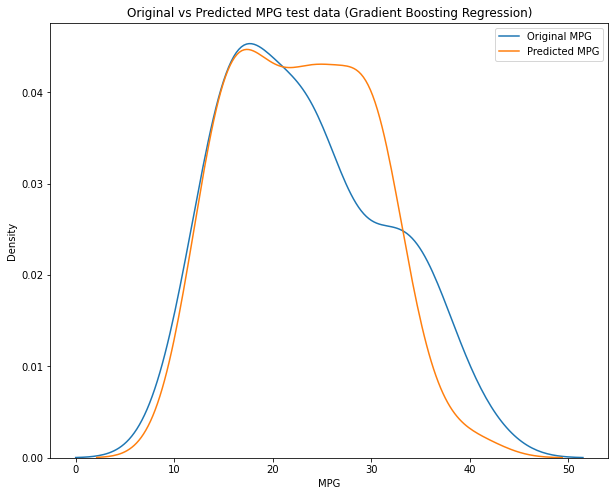

In [275]:
plt.figure(figsize = (10, 8))
sns.distplot(y_test, hist = False, label = "Original MPG")
sns.distplot(GBR_pred, hist = False, label = "Predicted MPG")
plt.title("Original vs Predicted MPG test data (Gradient Boosting Regression)")
plt.legend()
plt.xlabel("MPG")

<a id = "2"></a><br>
# Artificial Neural Network

In [276]:
# ANN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [277]:
def build_model():
    model = keras.models.Sequential([
        layers.Dense(units = 64, kernel_initializer = 'normal', activation = 'relu', input_shape = [len(X.keys())]),
        layers.Dense(units = 64, kernel_initializer = 'normal', activation = 'relu'),
        layers.Dense(units = 1)])
    model.compile(loss = 'mean_squared_error', optimizer = 'adam', metrics = ['mean_absolute_error', 'mean_squared_error'])
    return model


In [278]:
model = build_model()

In [279]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 64)                1664      
_________________________________________________________________
dense_1 (Dense)              (None, 64)                4160      
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 65        
Total params: 5,889
Trainable params: 5,889
Non-trainable params: 0
_________________________________________________________________


In [280]:
# Display the training progress by printing a single dot for each complted epoch
class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch%500 == 0:print('')
        if epoch%5 == 0:print('.', end = '')
EPOCHS = 1000
history = model.fit(X_train, y_train, epochs = EPOCHS, validation_split = 0.2,
                  verbose = 0, callbacks = [PrintDot()]) #calculate print dot


....................................................................................................
....................................................................................................

In [281]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mean_absolute_error,mean_squared_error,val_loss,val_mean_absolute_error,val_mean_squared_error,epoch
995,1.276724,0.695614,1.276724,11.833906,2.453685,11.833906,995
996,1.280442,0.687336,1.280442,11.991610,2.484917,11.991610,996
997,1.291776,0.706138,1.291776,11.855507,2.468822,11.855507,997
998,1.279248,0.689473,1.279248,11.935070,2.461759,11.935070,998
999,1.279914,0.691290,1.279914,11.957920,2.476611,11.957920,999


## Plot the graph of Number of epochs vs/ training and validation loss

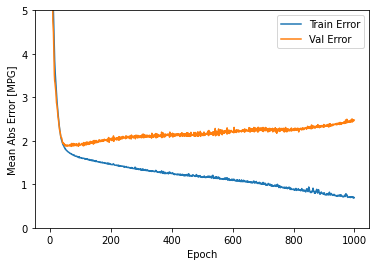

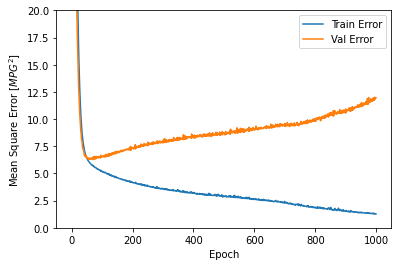

In [282]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error [MPG]')
  plt.plot(hist['epoch'], hist['mean_absolute_error'], label = 'Train Error')
  plt.plot(hist['epoch'], hist['val_mean_absolute_error'], label = 'Val Error')
  plt.ylim([0, 5])
  plt.legend()

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error [$MPG^2$]')
  plt.plot(hist['epoch'], hist['mean_squared_error'], label = 'Train Error')
  plt.plot(hist['epoch'], hist['val_mean_squared_error'], label = 'Val Error')
  plt.ylim([0, 20])
  plt.legend()
  plt.show()


plot_history(history)

* **From the above plot we can say that model is overfitting, so we need to perform early stopping which is used to avoid overfitting problem.**

In [283]:
# Applying early stopping method to avoid overfitting
model = build_model()

# The patience is the amount of epochs to check for improvement
early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 10)

history = model.fit(X_train, y_train,
                    epochs = EPOCHS, validation_split = 0.2, 
                    verbose = 0, callbacks = [early_stop, PrintDot()])


.............

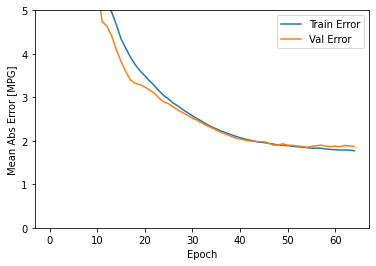

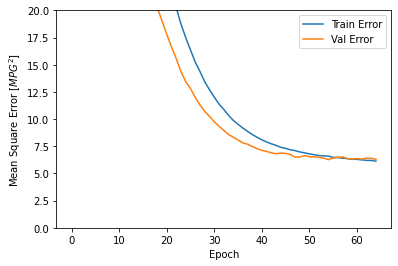

In [284]:
plot_history(history)

## Evaluate the model and predict it on testing data

In [285]:
# Evaluating the model
mse = model.evaluate(X_test, y_test, verbose = 0)
print('Testing set Mean Abs Error:', mse)

Testing set Mean Abs Error: [6.911032676696777, 1.9425952434539795, 6.911032676696777]


In [286]:
# Predicting the model
test_predictions = model.predict(X_test).flatten()
train_predictions = model.predict(X_train).flatten()

## Plot between actual values v/s predicted values (regression line and scatter plot)



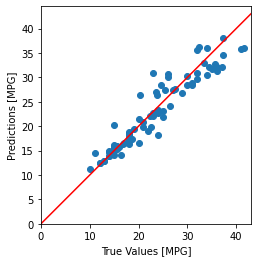

In [287]:
plt.scatter(y_test,test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
plt.plot([-100,100], [-100,100], color = 'red')
plt.show()

In [288]:
# calculating the mean-squared error, mean absolute error, and the R-Squared error on training and testing.

mse = mean_squared_error(y_test, test_predictions)
print('MSE is', mse)

mae = mean_absolute_error(y_test, test_predictions)
print('MAE is', mae)

rsq = r2_score(y_train, train_predictions)
print('R-square, Training is', rsq)

rsq = r2_score(y_test, test_predictions)
print('R-square, Testing is', rsq)

MSE is 6.911032168980974
MAE is 1.9425955367088321
R-square, Training is 0.8981368203683712
R-square, Testing is 0.8910917419924639


In [289]:
# Predict the Test set results
# Threshold of predicted probability = 0.5
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)
print(y_pred)

[[ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]
 [ True]]


In [290]:
comp_dx = {'Algorithms':['Linear Regression', 'Support Vector Regression', 
                         'Decision Tree Regression', 'Random Forest Regression',
                         'KNeighbors Regression', 'Gradient Boosting Regression'],
           'Training Score':[LR_score, SVR_score, DTR_score, RFG_score, KNR_score, GBR_score],
           'R2 Score':[LR_r2score, SVR_r2score, DTR_r2score, RFG_r2score, KNR_r2score, GBR_r2score],
           'RMSE':[LR_mse, SVR_mse, DTR_mse, RFG_mse, KNR_mse, GBR_mse]}

In [291]:
com_df = pd.DataFrame(comp_dx)
com_df.style.background_gradient(cmap = 'summer_r')

,Algorithms,Training Score,R2 Score,RMSE
0,Linear Regression,0.867975,0.875970,7.870628
1,Support Vector Regression,0.845841,0.852952,9.331257
2,Decision Tree Regression,1.000000,0.751709,15.755875
3,Random Forest Regression,0.974615,0.799684,12.711541
4,KNeighbors Regression,0.857306,0.805821,12.322118
5,Gradient Boosting Regression,1.000000,0.834816,10.482168
